<fieldset style="padding:10px; border:1px solid #ccc; box-shadow:2px 2px 5px rgba(0,0,0,0.1);">
<legend style="font-size: 10px; color:#555;">Credits</legend>

<table style="width: 100%; border-collapse: collapse;">
    <tr>
        <td style="width: 80px; vertical-align: top;">
            <img src="https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/logo/logo_b_text_lowres.png" alt="AstroStat Academy logo" width="100">
        </td>
        <td style="vertical-align: center; padding-left: 15px; font-size: 10px; line-height: 1.2;">
            Original work by the authors unless stated otherwise; external material is credited to its source.
            Licensed under the <a href="https://www.gnu.org/licenses/gpl-3.0.en.html">GNU GPLv3</a>.
        </td>
    </tr>
</table>

</fieldset>
<!-- Allow these <br> or it will look ugly once rendered on Jupyter Book. -->
<br>

# Neural Network Explainability <a class="tocSkip">

We open the black box: train neural networks, then ask them **why** they predict what they predict.

We will cover (with **intermediate tasks**):

- the simplest attribution method — **saliency maps** — and its failure mode
- a fix: **integrated gradients**, with a built-in correctness check
- both methods on a real model: **MNIST** (trained live) and **ImageNet** (pretrained)
- a first taste of **mechanistic explainability**: how circuits form across layers
- the full pipeline on a **galaxy morphology** classifier, ending with real DECaLS images

$\rightarrow$ You will leave with a small, working **explainability toolbox** you can apply, <u>as is</u>, to your own models and research.

# Setup

In [15]:
#!pip install torch torchvision --quiet       # already installed on Colab
#!pip install transformers datasets --quiet    # only for the optional Galaxy10 cell
from torchvision.models import resnet18, ResNet18_Weights

In [16]:
# On Colab: clone the course repository and cd into the notebook's folder,
# so that local files behave exactly as in the repo. (No effect locally.)
import requests

url = "https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/colab/clone_and_cd_colab.py"
colab = requests.get(url).text
exec(colab)

Running locally, skipping Colab setup.


In [17]:
# Set the global plotting style. This also imports matplotlib (as plt)
# and seaborn -> do NOT import them again below.
import requests

url = "https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/styles/plot_style.py"
style = requests.get(url).text
exec(style)

Imported matplotlib.
Imported seaborn.
Plotting style set.


In [18]:
# core numerics + PyTorch
import numpy as np
import torch
import torch.nn as nn              # layers (Linear, Conv2d, ...)
import torch.nn.functional as F    # stateless ops (relu, cross_entropy, ...)

# fix all random seeds -> everyone in the room gets the same results
torch.manual_seed(0)
np.random.seed(0)


device: cpu


# Why Explainability/Interpretability?

Neural networks are **excellent fitters** and **terrible explainers**. A trained CNN can classify galaxies as well as an expert — but it gives us a prediction, not a *reason*.

For science that matters, for three reasons:

> **Trust**: before publishing a catalog built by a classifier, we want evidence it uses *physics* (morphology, colors), not *artifacts* (PSF shape, background level, survey origin).
>
> **Debugging**: when a model fails, attribution shows *what it was looking at* — often the fastest route to bad labels or biased training data.
>
> **Discovery**: occasionally the model has learned something we have not. What it learned can point back at the science.


## How to deal with an explainability/interpretability question (Overview)

Attribution methods can *lie*. Standard methodology:

> **1. Pick a method and understand its assumptions**
>
> **2. Sanity-check it on a problem where the answer is known**
>
> **3. Apply it to the real model**
>
> **4. Verify: check axioms, ablate, compare methods**
>
> **5. Only then: trust (some of) the explanation**

# **Feature Attribution-Based Explainability/Interpretability**

## Peeking Inside the Black Box

Our model is a function $F$ that eats an input vector $x = (x_1, \ldots, x_d)$ — tabular features, or pixels — and returns a **score** (e.g. the logit for a class).

We want one number per feature answering: *"How much does feature $i$ matter for this score?"*


<img src="images/memes/attribution.png" style="display:block; margin-left:auto; margin-right:auto;">


## Why Learn/Use This for Science?

Even a rough understanding of *how* a neural network reaches its predictions turns it from a black box into a **hypothesis-generating instrument**. The attribution methods we build below (saliency maps and integrated gradients) point to the parts of the input the network relies on most. These pointers are not conclusions on their own — they are **hypotheses about which features matter**, which we can then test with targeted experiments and turn into real scientific results.

---

Two examples:

<u>**Cosmology: reading the cosmic web**</u>

A CNN is trained on maps of the **cosmic web** from simulated universes to predict the cosmological parameters $\Omega_m$ and $\sigma_8$. On its own, the network just outputs numbers. But the **attribution** maps below reveal *which structures* in the map drive the prediction — filaments, voids, dense knots.

<img src="images/cosmic_web_saliency.png" width=800 style="display:block; margin-left:auto; margin-right:auto;">


This suggests a hypothesis: *these structures carry the cosmological information.* We can then design controlled experiments — mask them out, degrade them, or vary them and watch how the parameter estimates respond — and arrive at a physical conclusion about **where** $\Omega_m$ and $\sigma_8$ are encoded in the large-scale structure.

---

<u>**Astrophysics: which emission lines trace star formation?**</u>

Suppose a network predicts a galaxy's **star-formation rate (SFR)** from a set of emission lines. The feature (individual lines) attributions **highlight the handful of lines the network leans on most**.

<img src="images/sfr_emission_lines_saliency.png" width=800 style="display:block; margin-left:auto; margin-right:auto;">



This directly attacks a practical problem: *which lines are worth precious telescope time?* Instead of observing every line, we can run follow-up studies using only the most important ones — making observing campaigns cheaper and more focused, while still capturing the SFR signal.

---

The common thread: **explainability tells us where to look, and good science does the rest.**

---

<!--
Trimmed for a physicist audience: they know Taylor expansions and vector calculus cold, so the
1D refresher and the long expository paragraphs are gone. Equations kept (that's what the user
said helps); surrounding prose cut to one line per idea.
-->

<!--
Trimmed for a physicist audience: they know Taylor expansions and vector calculus cold, so the
1D refresher and the long expository paragraphs are gone. Equations kept (that's what the user
said helps); surrounding prose cut to one line per idea.
-->

## Gradients as Local Sensitivity

Let $F:\mathbb{R}^d \to \mathbb{R}$ be the trained network. Forget the layers and the millions of weights for a moment — from the outside, $F$ is just a differentiable scalar function of a $d$-dimensional input $\bm{x} = (x_1,\ldots,x_d)$. That's the only property we'll use: $F$ is differentiable, so we can ask precisely **how it responds to a small nudge in $\bm{x}$**.

---

<u>**First-Order Taylor Expansion**</u>

If we expand $F$ around $\bm{x}$ (Taylor expansion), then truncate. The full expansion, keeping every order, is

$$F(\bm{x}+\bm{\delta}) \;=\; F(\bm{x}) \;+\; \sum_{i=1}^d \frac{\partial F}{\partial x_i}(\bm{x})\,\delta_i \;+\; \frac{1}{2}\sum_{i,j=1}^d \frac{\partial^2 F}{\partial x_i\partial x_j}(\bm{x})\,\delta_i\delta_j \;+\; \cdots$$

We keep the constant and linear terms and lump everything from the quadratic term on — the Hessian and beyond — into a single remainder, $O(\|\bm{\delta}\|^2)$ [shorthand for "shrinks at least as fast as $\|\bm{\delta}\|^2$], and so for small $\bm{\delta}$ it's negligible next to the linear term. That gives the working, first-order form:

$$F(\bm{x}+\bm{\delta}) \;=\; F(\bm{x}) \;+\; \sum_{i=1}^d \frac{\partial F}{\partial x_i}(\bm{x})\,\delta_i \;+\; O(\|\bm{\delta}\|^2)$$

$\bm{\delta}$ pushes every input coordinate at once, and the sum just totals up, feature by feature, how much each little push $\delta_i$ moves $F$. Stack those $d$ partial derivatives into one vector — the **gradient**:

$$\bm{\nabla} F(\bm{x}) \;=\; \left(\frac{\partial F}{\partial x_1}(\bm{x}), \ldots, \frac{\partial F}{\partial x_d}(\bm{x})\right)$$

and the sum collapses into a dot product, so the expansion reads:

$$\boxed{F(\bm{x}+\bm{\delta}) \;\approx\; F(\bm{x}) + \bm{\nabla} F(\bm{x})\cdot \bm{\delta}}$$


---

<u>**What $\bm{\nabla} F(\bm{x})$ Is**</u>

$\bm{\nabla} F(\bm{x})$ is the vector of coefficients that makes the equation above the best linear approximation to $F$ near $\bm{x}$. For explainability, the reading that matters is **per-feature**: component $i$ is exactly how much $F$ shifts per unit nudge of $x_i$ alone, everything else fixed —

$$\left(\bm{\nabla} F(\bm{x})\right)_i \;=\; \frac{\partial F}{\partial x_i}(\bm{x}) \;=\; \lim_{h\to 0}\frac{F(x_1,\ldots,x_i+h,\ldots,x_d)-F(\bm{x})}{h}$$

Large $\rightarrow$ $F$ cares about that feature here; near zero $\rightarrow$ it doesn't.


---

<u>**The Saliency Map**</u>

$\partial F/\partial x_i$ carries a sign: positive contributes toward the output, negative contributes against it. Both are real contributions — we only care *which features matter*, not the direction — so we keep the size and drop the sign:

$$S_i(\bm{x}) = \left| \frac{\partial F(\bm{x})}{\partial x_i} \right|$$

One importance score per feature [visualized as a heatmap for images].

---



## **Sanity Check**: A Toy Classifier

Before pointing this at, like, a massive ResNet or whatever, let's build a synthetic dataset with known ground truth and a simple single-layer network:
>
> * The label depends *only* on **Feature 0**.
>
> * **Feature 1** is pure noise.
>

$\rightarrow$ A good attribution method **must** assign all importance to Feature 0. High importance on Feature 1 means the *method* is broken — not the model. Let's code this up.

<img src="images/toy_classifier_arch.png" style="display:block; margin-left:auto; margin-right:auto;">

<table><tr><td width=1100><center><br>
    Architecture of the toy classifier used to sanity-check saliency and Integrated Gradients (IG): 2 input features, 16 hidden units, 2 output classes.<br>
<br></center></td></tr></table>


In [19]:
# ---- data: 500 points, 2 features -----------------------------------
X = torch.randn(500, 2)       # both features ~ N(0, 1)
y = (X[:, 0] > 0).long()      # label depends ONLY on feature 0
                              # -> ground-truth importances: (1, 0)
print(f"data: {X.shape[0]} points, {X.shape[1]} features, {y.unique().numel()} classes")

# ---- a tiny MLP classifier -------------------------------------------
toy_model = nn.Sequential(nn.Linear(2, 16),   # 2 features -> 16 hidden units
                          nn.ReLU(),
                          nn.Linear(16, 2))   # -> 2 class logits
opt = torch.optim.Adam(toy_model.parameters(), lr=0.01)
n_params = sum(p.numel() for p in toy_model.parameters())
print(f"model: {n_params:,} parameters")

# ---- standard training loop (full batch, 300 steps) ------------------
print("training...")
for step in range(300):
    opt.zero_grad()                           # reset gradients
    loss = F.cross_entropy(toy_model(X), y)   # classification loss
    loss.backward()                           # backprop
    opt.step()                                # update the weights
    if (step + 1) % 50 == 0:
        acc = (toy_model(X).argmax(1) == y).float().mean()
        print(f"  step {step + 1:3d}/300   loss {loss.item():.4f}   train accuracy {acc:.1%}")

acc = (toy_model(X).argmax(1) == y).float().mean()
print(f"done -- final train accuracy {acc:.1%}")   # ~99%: the task is easy


data: 500 points, 2 features, 2 classes
model: 82 parameters
training...
  step  50/300   loss 0.1107   train accuracy 98.8%
  step 100/300   loss 0.0492   train accuracy 99.0%
  step 150/300   loss 0.0314   train accuracy 99.2%
  step 200/300   loss 0.0234   train accuracy 99.6%
  step 250/300   loss 0.0192   train accuracy 99.6%
  step 300/300   loss 0.0165   train accuracy 99.8%
done -- final train accuracy 99.8%


---

### Briefly looking inside how the neural network learns:

For neurons in a neural network:

$$ a^{(l)} = \sigma\!\left(W^{(l)} a^{(l-1)} + b^{(l)}\right) $$

It learns by scoring its error with a loss $\mathcal{L}$, then nudging every weight against the gradient:

$$ W \;\leftarrow\; W - \eta\, \frac{\partial \mathcal{L}}{\partial W} $$



<img src="images/backprop.png" width=800 style="display:block; margin-left:auto; margin-right:auto;">


**Backpropagation** is the chain rule, applied layer by layer, computing all these weight gradients at once — and the recipe doesn't care what you point it at. Explainability points it somewhere else entirely: not how the loss moves with each weight, but **how the output $F(\bm{x})$ moves with each input feature**. Here's what that looks like in practice with **PyTorch**:

PyTorch records every forward op in a computational graph; `score.backward()` walks it backward, filling `.grad` on every tensor with `requires_grad=True`.

Normally that means reading `weight.grad`. For saliency, redirect it: set `x.requires_grad_(True)` and read `x.grad` instead — same call, different tensor.

One backward call gets all $d$ sensitivities — why saliency maps are cheap.

---

Averaged over 100 fresh test points, saliency should give (almost) all importance to feature 0:

computing saliency on 100 fresh test points...
mean |gradient| -- feature 0 (signal): 11.534   feature 1 (noise): 0.300


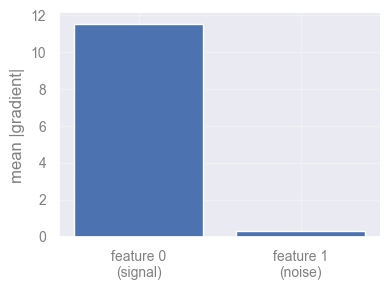

In [41]:
#-------------------------------------------------------------------------------------

def saliency(model, x, target):
    """|d F_target / d x| for a single input x (1-D tensor)."""

    x = x.clone().detach().requires_grad_(True)   # track gradients on the INPUT

    score = model(x.unsqueeze(0))[0, target]      # the scalar we explain: one logit

    score.backward()                              # d(score)/d(x) -> stored in x.grad

    return x.grad.abs()                           # keep the magnitude only

#-------------------------------------------------------------------------------------


# average the saliency of the PREDICTED class over 100 fresh test points
N_TEST = 100
print(f"computing saliency on {N_TEST} fresh test points...")
X_test = torch.randn(N_TEST, 2)
saliencies = []
for xi in X_test:

#-------------------------------------------------------------------------------------

    pred = toy_model(xi.unsqueeze(0)).argmax().item()

    saliencies.append(saliency(toy_model, xi, pred))

#-------------------------------------------------------------------------------------

sal = torch.stack(saliencies).mean(0)   # (2,): mean |gradient| per feature
print(f"mean |gradient| -- feature 0 (signal): {sal[0]:.3f}   feature 1 (noise): {sal[1]:.3f}")

fig = plt.figure(figsize=(4, 3))
plt.bar(["feature 0\n(signal)", "feature 1\n(noise)"], sal.numpy())
plt.ylabel("mean |gradient|")
plt.tight_layout()
plt.show()


<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit; box-sizing: border-box; max-width: 100%; overflow-wrap: break-word;">

<font size=4>**Question**</font>

We took the **absolute value** of the gradient. What information does the *sign* carry — and when would you want to keep it?

</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a; box-sizing: border-box; max-width: 100%; overflow-wrap: break-word;">
<details>

<b><summary>[Spoiler] (click here to expand)</summary></b>

The sign is the <b>direction</b>: positive means <i>increasing</i> this feature <i>increases</i> the class score. For "which features matter at all", magnitude suffices. Sign matters for "does this pixel argue <i>for</i> or <i>against</i> the class?"

</details>
</div>

## Saturation: where saliency fails

Gradients are **local**. A well-trained, **confident** network sits on a **flat plateau**: small wiggles change nothing.

$\rightarrow$ On a plateau the gradient is $\approx 0$, *even for the features that caused the prediction*.


Watch it happen on a **single sigmoid "neuron"**, and side by side on a **function of a ReLU unit with the same kind of flat region** — a smooth asymptote vs. a hard, exact-zero cliff:

gradient at x=2.5 (a confidently-large input):
  sigmoid(4x)         : 0.0002
  1 - ReLU(1 - x)     : -0.0000


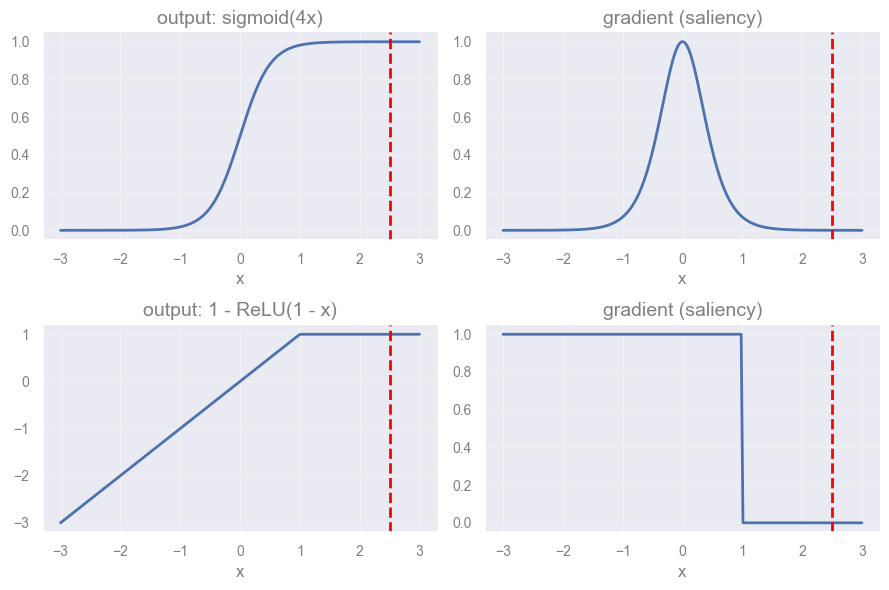

In [42]:
# a single, very confident "neuron": output = sigmoid(4x)
xs = torch.linspace(-3, 3, 200, requires_grad=True)
ys = torch.sigmoid(4 * xs)
ys.sum().backward()                # gradient of the output at every x, in one go

# same story with a ReLU-based saturating function: output = 1 - relu(1 - x)
xs_relu = torch.linspace(-3, 3, 200, requires_grad=True)
ys_relu = 1 - F.relu(1 - xs_relu)
ys_relu.sum().backward()

CONFIDENT_X = 2.5   # a "confidently-classified" input
print(f"gradient at x={CONFIDENT_X} (a confidently-large input):")
idx = (xs.detach() - CONFIDENT_X).abs().argmin()
print(f"  sigmoid(4x)         : {xs.grad[idx].item():.4f}")
idx_relu = (xs_relu.detach() - CONFIDENT_X).abs().argmin()
print(f"  1 - ReLU(1 - x)     : {xs_relu.grad[idx_relu].item():.4f}")

fig, ax = plt.subplots(2, 2, figsize=(9, 6))
ax[0, 0].plot(xs.detach(), ys.detach())
ax[0, 0].set_title("output: sigmoid(4x)")
ax[0, 1].plot(xs.detach(), xs.grad)   # <- this IS the saliency, at every x
ax[0, 1].set_title("gradient (saliency)")

ax[1, 0].plot(xs_relu.detach(), ys_relu.detach())
ax[1, 0].set_title("output: 1 - ReLU(1 - x)")
ax[1, 1].plot(xs_relu.detach(), xs_relu.grad)
ax[1, 1].set_title("gradient (saliency)")

for row in ax:
    for a in row:
        a.axvline(CONFIDENT_X, color="red", ls="--")   # a confidently-classified input
        a.set_xlabel("x")
plt.tight_layout()
plt.show()


**WARNING:** In the toy functions, a large $x$ pushes the output toward 1 by construction — so at $x = 2.5$ we *know* $x$ drove the output to $\approx 1$. Yet $x = 2.5$ sits deep in the flat plateau, where the gradient — and hence the saliency — is $\approx$ **zero**.

$\rightarrow$ Saliency would say this feature does not matter. That is <u>wrong</u> — exactly backwards.

<div style="border-left: 4px solid #2196F3; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #f0f8ff; color: #1a1a1a; box-sizing: border-box; max-width: 100%; overflow-wrap: break-word;">

<details>

<b><summary>What does "saturated" mean in the context of a neural network? (click here to expand)</summary></b>

Take a classifier for a yes/no question (*is this a cat?*). It ends in a **sigmoid**, which turns the network's internal score into a probability between 0 and 1; being **confident** just means that probability sits near 1 (*"definitely a cat"*) or near 0 (*"definitely not"*).

Think of the sigmoid as a glass of water that cannot overflow: once it is full to the brim (probability $\approx 1$), pouring in more changes nothing — it is already at the top, i.e., **saturated**. For a feel of the numbers, a raw score of, say, 0 gives 0.5 (a shrug), 4 gives about 0.98, and 8 about 0.9997 — notice how hard you must crank the score just to inch from 0.98 to 0.9997.

**Why do well-trained networks end up here?** Training rewards being *more* right with no penalty for over-confidence, so the easiest way to shrink the error is to "shout" — produce ever-bigger internal scores that the sigmoid pins closer to 1. The network learns to be very loud about answers it is sure of.

**Why that breaks saliency.** Saliency asks *"if I nudge this pixel, how much does the output move?"* — but on the flat, saturated top the output barely moves, even for a pixel that was the whole reason for the "cat" answer. So the features that actually mattered look unimportant. The frustrating trade-off: the more confident your classifier, the deeper its key features sit in this unresponsive zone, and the more vanilla saliency understates them. So how do we fix this?

</details>
</div>

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4>**Question**</font>

If saliency fails for confident, well-trained networks — why even learn it?

</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">
<details>

<b><summary>[Answer] (click here to expand)</summary></b>

Because it is the foundation the advanced methods build on — they are all **gradient** methods, and saliency is the gradient in its rawest form. It is the cheapest attribution to compute (one backward pass), it gives a useful **first-order approximation** of each feature's contribution, and seeing *when* and *why* it breaks is what teaches you to trust — or distrust — any attribution method. We do not drop saliency; we build on it.

</details>
</div>

<div style="border-left: 4px solid #2196F3; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #f0f8ff; color: #1a1a1a; box-sizing: border-box; max-width: 100%; overflow-wrap: break-word;">

<details>

<b><summary>[Why completeness holds] (click here to expand)</summary></b>

We want $\sum_i \mathrm{IG}_i(x) = F(x) - F(x')$.

Parametrise the straight path from baseline to input, $\gamma(\alpha) = x' + \alpha\,(x - x')$ with $\gamma(0)=x'$ and $\gamma(1)=x$, and let $g(\alpha) = F(\gamma(\alpha))$. By the fundamental theorem of calculus and the chain rule:

$$ F(x) - F(x') = \int_0^1 g'(\alpha)\, d\alpha = \int_0^1 \sum_i \frac{\partial F(\gamma(\alpha))}{\partial x_i}\,\frac{d\gamma_i}{d\alpha}\, d\alpha. $$

Since $\gamma(\alpha) = x' + \alpha\,(x - x')$, each coordinate moves at constant speed:

$$ \frac{d\gamma_i}{d\alpha} = x_i - x'_i. $$

Substituting and pulling the constants $(x_i - x'_i)$ out of the integral:

$$ F(x) - F(x') = \sum_i (x_i - x'_i)\int_0^1 \frac{\partial F(\gamma(\alpha))}{\partial x_i}\, d\alpha = \sum_i \mathrm{IG}_i(x). \qquad \blacksquare $$

</details>
</div>

<img src="images/midpoint_riemann_sum.png" width=600 style="display:block; margin-left:auto; margin-right:auto;">

<table><tr><td width=1100><center><br>
    Schematic depiction of a midpoint Riemann sum<br>
<br></center></td></tr></table>


---

## **Toy Model:** A network that saturates by construction

$$ F(x) = 1 - \mathrm{ReLU}(1 - x_1 - x_2) \quad \rightarrow \quad \text{flat (gradient } \boldsymbol{0}\text{) once } x_1 + x_2 \ge 1 $$

In [43]:
class SaturatedNet(nn.Module):
    """F(x) = 1 - relu(1 - x1 - x2): output stuck at 1 once x1 + x2 >= 1."""
    def forward(self, x):
        return 1 - torch.relu(1 - x[..., 0] - x[..., 1])


saturated_model = SaturatedNet()

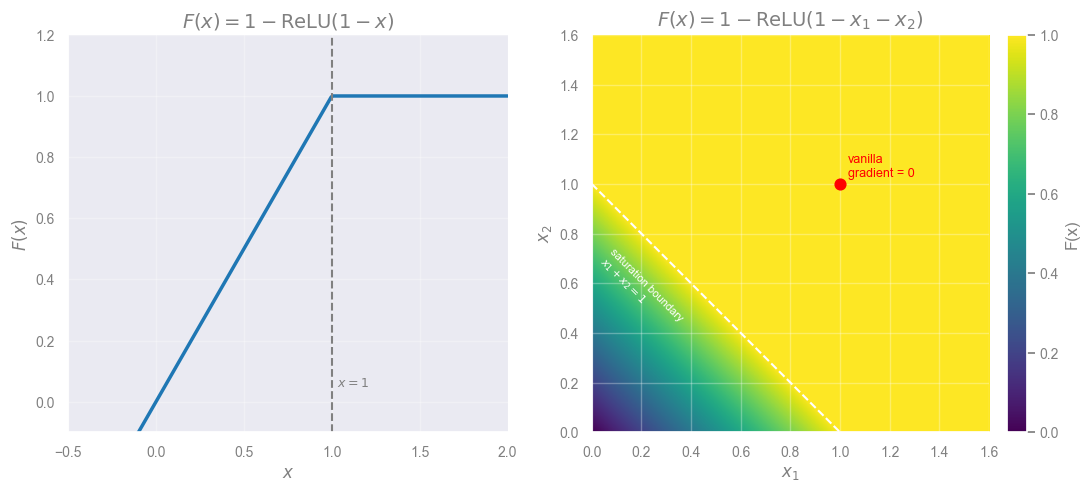

vanilla gradient at (1,1): [0. 0.]   <- sees nothing!


In [44]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))

# ---- panel 1: 1D version, F(x) = 1 - ReLU(1 - x) --------------------------
x1d = np.linspace(-0.5, 2, 300)
y1d = 1 - np.maximum(0, 1 - x1d)
ax1.plot(x1d, y1d, color="tab:blue", linewidth=2.5)
ax1.axvline(1, color="gray", linestyle="--", linewidth=1.5)
ax1.text(1.03, 0.05, "$x=1$", color="gray", fontsize=9)
ax1.set_xlabel("$x$")
ax1.set_ylabel("$F(x)$")
ax1.set_title(r"$F(x) = 1 - \mathrm{ReLU}(1 - x)$")
ax1.set_xlim(-0.5, 2)
ax1.set_ylim(-0.1, 1.2)

# ---- panel 2: 2D version, same function as later -- just the surface and
# the saturation boundary, nothing else -------------------------------------
xx, yy = np.meshgrid(np.linspace(0, 1.6, 300), np.linspace(0, 1.6, 300))
zz = 1 - np.maximum(0, 1 - xx - yy)
im = ax2.imshow(zz, extent=[0, 1.6, 0, 1.6], origin="lower",
                cmap="viridis", vmin=0, vmax=1)
ax2.set_xlim(0, 1.6)
ax2.set_ylim(0, 1.6)
ax2.set_aspect("equal")
cbar = fig.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
cbar.set_label("F(x)")

line_x = np.linspace(0, 1.6, 2)
ax2.plot(line_x, 1 - line_x, color="white", linestyle="--", linewidth=1.5)
ax2.text(0.02, 0.75, "saturation boundary\n$x_1+x_2=1$", color="white",
         fontsize=8, ha="left", va="top", rotation=-45)

# the point where vanilla gradient is 0 (computed further down)
ax2.scatter([1], [1], color="red", s=60, zorder=5)
ax2.text(1.03, 1.03, "vanilla\ngradient = 0", color="red", fontsize=9)

ax2.set_xlabel("$x_1$")
ax2.set_ylabel("$x_2$")
ax2.set_title(r"$F(x) = 1 - \mathrm{ReLU}(1 - x_1 - x_2)$")

plt.tight_layout()
plt.show()


# vanilla saliency at x = (1, 1): both features clearly pushed F from 0 to 1,
# but the output is flat there...
xg = torch.tensor([1.0, 1.0], requires_grad=True)
saturated_model(xg.unsqueeze(0)).squeeze().backward()
print("vanilla gradient at (1,1):", xg.grad.numpy(), "  <- sees nothing!")


Implementation: midpoint **Riemann sum** along the path, then two checks —

* does IG see what the vanilla gradient missed,
* and does **completeness** hold?

In [65]:
#-------------------------------------------------------------------------------------

def integrated_gradients(model, x, baseline=None, target=None, steps=64):
    """IG for a single input x. Batched: the whole path in one pass."""

    if baseline is None:
        baseline = torch.zeros_like(x)      # default: "absence of signal"

    # midpoints of `steps` sub-intervals
    alphas = torch.linspace(0, 1, steps + 1)[:-1] + 0.5 / steps

    # stack ALL path points into one batch, shape (steps, *x.shape), so the
    alphas = alphas.reshape((steps,) + (1,) * x.dim())
    path = (baseline + alphas * (x - baseline)).requires_grad_(True)

    # whole path goes through the model in a single forward + backward pass
    out = model(path)                                    # (steps, ...) in one pass

    score = out.sum() if target is None else out[:, target].sum()
    
    score.backward()                                     # one backward -> path.grad

    # Riemann sum = mean gradient along the path, times the displacement
    return (x - baseline) * path.grad.mean(0)

#-------------------------------------------------------------------------------------


# the saturated point from before
x = torch.tensor([1.0, 1.0])
ig = integrated_gradients(saturated_model, x, steps=256)
print("IG at (1,1):", ig.detach().numpy())      # ~(0.5, 0.5): credit restored!

# completeness: attributions must sum to the total change in output
delta = (saturated_model(x.unsqueeze(0)) - saturated_model(torch.zeros(1, 2))).item()
print(f"sum(IG) = {ig.sum():.4f}  vs  F(x) - F(baseline) = {delta:.4f}")

IG at (1,1): [0.5 0.5]
sum(IG) = 1.0000  vs  F(x) - F(baseline) = 1.0000


### Let's Visualise:

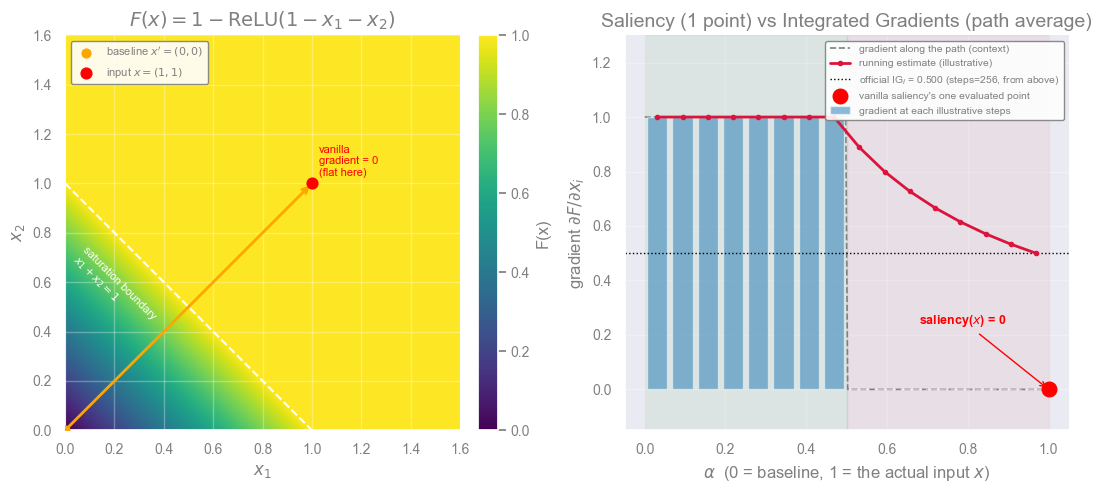

In [66]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))

# ---- panel 1: F(x1, x2) -- ramp then flat plateau ------------------------
xx, yy = np.meshgrid(np.linspace(0, 1.6, 300), np.linspace(0, 1.6, 300))
zz = 1 - np.maximum(0, 1 - xx - yy)                  # F(x1, x2)
im = ax1.imshow(zz, extent=[0, 1.6, 0, 1.6], origin="lower",
                cmap="viridis", vmin=0, vmax=1)
ax1.set_xlim(0, 1.6)
ax1.set_ylim(0, 1.6)
ax1.set_aspect("equal")
cbar = fig.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)
cbar.set_label("F(x)")

# saturation boundary: x1 + x2 = 1 -- everything past it is a flat plateau
line_x = np.linspace(0, 1.6, 2)
ax1.plot(line_x, 1 - line_x, color="white", linestyle="--", linewidth=1.5)
ax1.text(0.02, 0.75, "saturation boundary\n$x_1+x_2=1$", color="white",
         fontsize=8, ha="left", va="top", rotation=-45)

# the straight-line path IG integrates over: baseline (0,0) -> input x (the
# SAME x already used for the official IG run above). It crosses the ramp
# (where the gradient is actually nonzero) before landing on the plateau --
# a single point-gradient at x never sees that.
ax1.annotate("", xy=(x[0].item(), x[1].item()), xytext=(0, 0),
             arrowprops=dict(arrowstyle="->", color="orange", lw=2))
ax1.scatter([0], [0], color="orange", s=40, zorder=5, label="baseline $x'=(0,0)$")
ax1.scatter([x[0].item()], [x[1].item()], color="red", s=60, zorder=5, label="input $x=(1,1)$")
ax1.text(1.03, 1.03, "vanilla\ngradient = 0\n(flat here)", color="red", fontsize=8)

ax1.set_xlabel("$x_1$")
ax1.set_ylabel("$x_2$")
ax1.set_title(r"$F(x) = 1 - \mathrm{ReLU}(1 - x_1 - x_2)$")
leg1 = ax1.legend(loc="upper left", fontsize=8)
leg1.get_frame().set_facecolor("white")
leg1.get_frame().set_alpha(0.9)

# ---- panel 2: vanilla saliency (one point) vs integrated gradients ------
# (path average). This reuses `x` and the already-computed `ig` from the
# official steps=256 run above -- IG itself is NOT recomputed here, only
# individual gradient evaluations for illustration.
alphas_fine = torch.linspace(0, 1, 200)
grad_vals = []
for a in alphas_fine:
    xp = (a * x).clone().detach().requires_grad_(True)
    saturated_model(xp.unsqueeze(0)).squeeze().backward()
    grad_vals.append(xp.grad[0].item())          # x1 == x2 by symmetry here

ax2.axvspan(0, 0.5, color="tab:green", alpha=0.08)
ax2.axvspan(0.5, 1, color="tab:red", alpha=0.06)
# the continuous gradient along the path -- context only, nobody evaluates
# this whole curve; drawn so you can see what the discrete samples below
# are sampling from.
ax2.plot(alphas_fine, grad_vals, color="gray", linewidth=1.2, linestyle="--",
         label="gradient along the path (context)", zorder=1)

# a handful of discrete midpoint samples of that same curve, purely to show
# what a Riemann sum looks like -- deliberately fewer than the steps=256
# used in the official run above, just for a legible bar chart.
STEPS = 16
alphas_mid = (torch.arange(STEPS) + 0.5) / STEPS
grad_samples = []
for a in alphas_mid:
    xp = (a * x).clone().detach().requires_grad_(True)
    saturated_model(xp.unsqueeze(0)).squeeze().backward()
    grad_samples.append(xp.grad[0].item())
grad_samples = np.array(grad_samples)
running_ig = np.cumsum(grad_samples) / np.arange(1, STEPS + 1)   # (x_i - baseline_i) = 1

ax2.bar(alphas_mid.numpy(), grad_samples, width=0.8 / STEPS, color="tab:blue",
        alpha=0.5, zorder=2, label=f"gradient at each illustrative steps")
ax2.plot(alphas_mid.numpy(), running_ig, color="crimson", marker="o", markersize=3,
         zorder=3, label="running estimate (illustrative)")
ax2.axhline(ig[0].item(), color="black", linestyle=":", linewidth=1,
            label=r"official IG$_i$ = %.3f (steps=256, from above)" % ig[0].item())

# vanilla saliency: a single point, at the actual input (alpha=1)
ax2.scatter([1.0], [0.0], color="red", s=110, zorder=5,
            label="vanilla saliency's one evaluated point")
ax2.annotate("saliency($x$) = 0", xy=(1.0, 0.0), xytext=(0.68, 0.24),
             fontsize=9, color="red", fontweight="bold",
             arrowprops=dict(arrowstyle="->", color="red"))

ax2.set_xlabel(r"$\alpha$  (0 = baseline, 1 = the actual input $x$)")
ax2.set_ylabel(r"gradient $\partial F/\partial x_i$")
ax2.set_title("Saliency (1 point) vs Integrated Gradients (path average)")
ax2.set_ylim(-0.15, 1.3)
leg2 = ax2.legend(loc="upper right", fontsize=7.5)
leg2.get_frame().set_facecolor("white")
leg2.get_frame().set_alpha(0.9)

plt.tight_layout()
plt.show()


<div style="border-left: 4px solid #2196F3; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #f0f8ff; color: #1a1a1a; box-sizing: border-box; max-width: 100%; overflow-wrap: break-word;">

**NOTE:** The first half of the path from $(0,0)$ to $(1,1)$ is *not* saturated — IG picks up the gradient there; the point-gradient at the end misses it.

Each feature gets $0.5$, summing to $F(x) - F(x') = 1$ (**completeness**).

</div>

<div style="border-left: 4px solid #4CAF50; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #e8f5e9; color: #1a1a1a; box-sizing: border-box; max-width: 100%; overflow-wrap: break-word;">

**Important take-away message #1**

An attribution without a *correctness check* is a rumor. Completeness makes IG a **measurement**: if attributions don't sum to $F(x) - F(x')$, increase `steps` (or fix your code).

</div>

**What have we achieved so far?**

<div style="border-left: 4px solid #4CAF50; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #e8f5e9; color: #1a1a1a; box-sizing: border-box; max-width: 100%; overflow-wrap: break-word;">

We understood two attribution methods and validated them on toy problems with known ground truth.

</div>

Now it is time for a **real model**.

# Demonstration on a **Real Model**: MNIST

Time to leave toy-land. We load a small CNN already trained on MNIST (70,000 digits, train/val/test split, ~98%+ test accuracy), saved as `models/mnist_cnn_full.pt` — no training here, just load and go.

Everything downstream — saliency, IG, the circuit diagram — is model-agnostic: it only assumes *a model that maps images to logits*. You'll later apply these exact same functions, unchanged, to ImageNet photos.

In [67]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class SmallCNN(nn.Module):
    """Two conv blocks + three linear layers (shapes for one image).

    Deliberately WIDER than the task needs (MNIST is easy) so the
    network has room to grow redundant units -- that redundancy is what
    the accuracy-vs-kept-fraction sweep further down relies on: a
    narrow, tightly-fit model has no slack left to prune.

    Only needed here so `torch.load` below can unpickle the saved model --
    no training happens in this notebook, the checkpoint was trained once
    and saved with `torch.save(model, MNIST_MODEL_PATH)`.
    """
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)   # (1,28,28)  -> (32,28,28)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)  # (32,14,14) -> (64,14,14)
        self.fc1 = nn.Linear(64 * 7 * 7, 256)         # flattened maps -> 256
        self.fc2 = nn.Linear(256, 128)                # 256 -> 128 (extra hidden layer)
        self.fc3 = nn.Linear(128, 10)                 # 128 -> 10 class logits

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), 2)    # 28 -> 14
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)    # 14 -> 7
        x = F.relu(self.fc1(x.flatten(1)))            # penultimate -> penultimate-1
        x = F.relu(self.fc2(x))                       # penultimate layer
        return self.fc3(x)                            # logits



MNIST_MODEL_PATH = "models/mnist_cnn_full.pt"

print(f"loading pretrained weights from {MNIST_MODEL_PATH}...")
model = torch.load(MNIST_MODEL_PATH, map_location="cpu", weights_only=False)
model.eval()

n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  {n_params:,} parameters total ({n_trainable:,} trainable)")
print("done -- model is ready for inference.")


loading pretrained weights from models/mnist_cnn_full.pt...
  856,074 parameters total (856,074 trainable)
done -- model is ready for inference.


<img src="images/MNIST_arch.png" style="display:block; margin-left:auto; margin-right:auto;">

<table><tr><td width=800><center><br>
    Figure 3. Architecture of the Convolutional Neural Network (CNN) used for the MNIST digit classifier.<br>
<br></center></td></tr></table>


## Saliency vs. IG

The question: *"**which pixels** made you say '8' (or 'tench')?"*

Both functions below are **shape-agnostic**: any `(C, H, W)` image, any model returning logits. We reduce over color channels and plot **absolute attributions** on a saturated scale: **white = no attribution**, **dark red** (saliency) / **dark blue** (IG) = strong attribution. IG is **vectorized** — the whole path goes through the model as one batch — with a black-image baseline: *"which pixels pushed the score up, starting from nothing?"*

test set: 10000 images, 10 classes


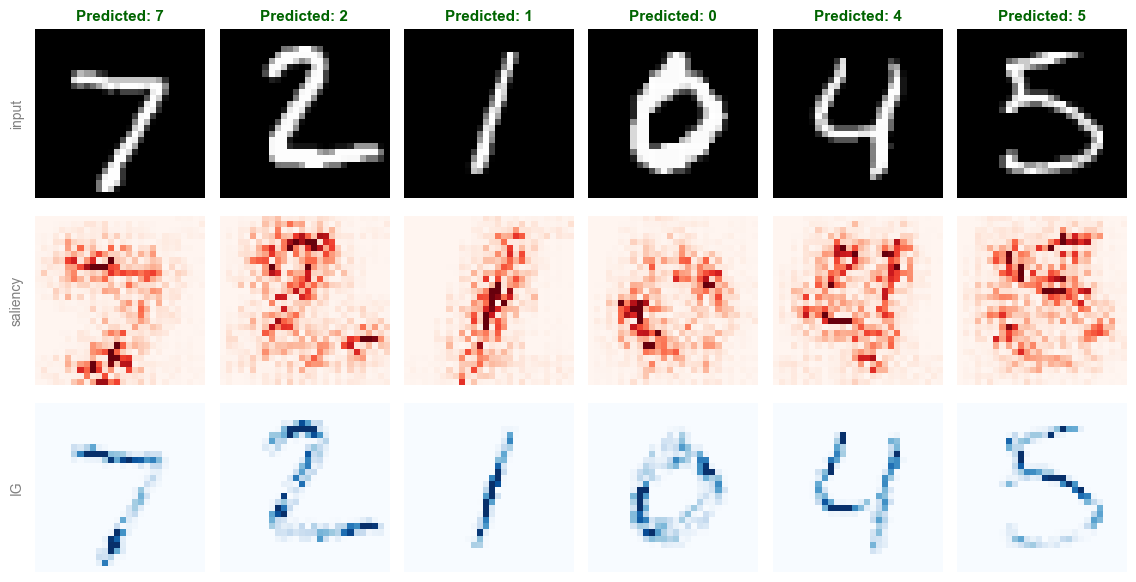

In [68]:
from torchvision import datasets, transforms

transform = transforms.ToTensor()           # PIL -> float tensor in [0, 1]
test_ds = datasets.MNIST("./data", train=False, download=True, transform=transform)
test_dl = torch.utils.data.DataLoader(test_ds, batch_size=256)
CLASS_NAMES = [str(i) for i in range(10)]
print(f"test set: {len(test_ds)} images, {len(CLASS_NAMES)} classes")

# a handful of test digits to interrogate (and their true labels)
examples = torch.stack([test_ds[i][0] for i in [0, 1, 2, 3, 4, 15]])
true_labels = [test_ds[i][1] for i in [0, 1, 2, 3, 4, 15]]
IG_STEPS = 64                                # small model -> many IG steps


def display_img(x):
    """Attribution-tensor -> (image for imshow, cmap)."""
    return x.squeeze(0).cpu(), "gray"


# ---- run the model once to get its predictions for these examples --------
with torch.no_grad():
    preds = model(examples).argmax(1).cpu().tolist()

# reuse the saliency() and integrated_gradients() defined earlier; both return a
# (C, H, W) tensor, so collapse the color channel to get a 2D map for plotting
sal_maps = [saliency(model, img, p).amax(0).cpu()
            for img, p in zip(examples, preds)]
ig_maps = [integrated_gradients(model, img, target=p, steps=IG_STEPS).sum(0).detach().cpu()
           for img, p in zip(examples, preds)]

fig, axes = plt.subplots(3, len(examples), figsize=(1.9 * len(examples), 6))
for j in range(len(examples)):
    im, cmap = display_img(examples[j])          # dataset-appropriate display
    axes[0, j].imshow(im, cmap=cmap)
    is_correct = preds[j] == true_labels[j]
    axes[0, j].set_title(f"Predicted: {CLASS_NAMES[preds[j]][:16]}", fontsize=11,
                         fontweight="bold", color="darkgreen" if is_correct else "darkred")
    for r, amap, cmap_a in [(1, sal_maps[j], "Reds"),
                            (2, ig_maps[j].abs(), "Blues")]:
        # sharp contrast: saturate the colormap at the 99th percentile,
        # so everything with real attribution shows up DARK
        vmax = torch.quantile(amap.flatten(), 0.99)
        axes[r, j].imshow(amap, cmap=cmap_a, vmin=0, vmax=vmax)
    for r in range(3):
        axes[r, j].axis("off")
for r, label in enumerate(["input", "saliency", "IG"]):
    axes[r, 0].text(-0.15, 0.5, label, transform=axes[r, 0].transAxes,
                    rotation=90, va="center", fontsize=10)
plt.tight_layout()
plt.show()

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4>**Question**</font>

Look at the 3 rows above. What do you notice?

</div>


<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">
<details>

<b><summary>[Answer] (click here to expand)</summary></b>

**Saliency** is noisy and finicky: a jittery, speckled map that only loosely follows the digit.

**IG** is cleaner and more accurate. Saliency reads the gradient at a single point — the actual input — which for a confidently-classified digit sits on a flat, **saturated** plateau: the local gradient is near 0, even for pixels that caused the prediction.

On the walk from the baseline (black image) to the real digit, the gradient is small at both ends: near the baseline there isn't enough evidence yet; near the real image the network has already reached its confident answer. Somewhere **in between**, the network is still actively revising its prediction — that's where the output changes fastest, so that's where the gradient is largest.

IG **averages the gradient along the whole path**, so it collects that middle stretch instead of only the endpoint where the gradient has flattened out. Same mechanism that fixed the toy saturated network earlier, now on a real model.

</details>
</div>

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit; box-sizing: border-box; max-width: 100%; overflow-wrap: break-word;">

<font size=4>**Question**</font>

Same model, same images — why is vanilla saliency so much **noisier** than IG?

</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a; box-sizing: border-box; max-width: 100%; overflow-wrap: break-word;">
<details>

<b><summary>[Spoiler] (click here to expand)</summary></b>

A ReLU network is piecewise linear: tiny input changes flip ReLUs on/off, so the <b>local gradient jumps around</b> pixel to pixel. Saliency reads that jittery gradient at one point and inherits the noise. IG <b>averages gradients over the whole path</b>, smoothing it away.

The clean <b>background</b> is a separate effect: IG multiplies by $(x - x')$, which is exactly 0 wherever the image already equals the baseline $x'$. Here the baseline is black, same as the background, so it silences itself. The <b>baseline is part of the question</b> — change it, and a different part of the image goes quiet instead.

</details>
</div>

# **Exercise**: Application to ImageNet

Saliency, IG, and the noise tunnel above were written to work on *any* model that maps images to logits, not just the MNIST CNN. Let's swap in a **pretrained ResNet-18** (1000-class ImageNet) and a handful of animal photos, and re-run the exact same functions unchanged.

### Importing model, weights and test images

<img src="images/resnet18_arch.png" style="display:block; margin-left:auto; margin-right:auto;">

<table><tr><td width=800><center><br>
    Figure 4. Architecture of the ResNet18 architecture used for classifying ImageNet data<br>
<br></center></td></tr></table>


accuracy on these 5 examples: 5/5 = 100%


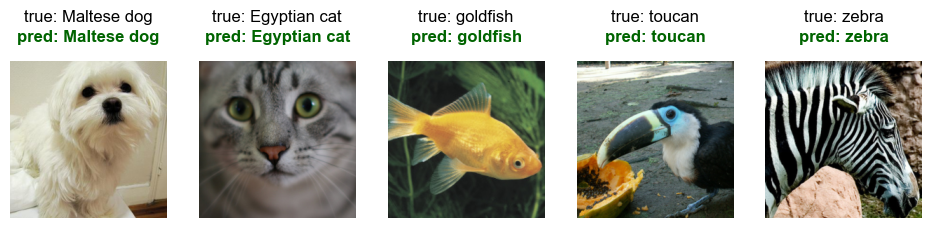

In [70]:
# ------------------------------- ImageNet: pretrained ResNet-18 (no training needed)
from io import BytesIO
from PIL import Image

weights = ResNet18_Weights.DEFAULT
imagenet_model = resnet18(weights=weights).eval()   # no training needed
preprocess = weights.transforms()                     # resize + crop + normalize
IMAGENET_CLASS_NAMES = weights.meta["categories"]      # the 1000 ImageNet labels

# five simple ANIMAL examples (one per class) -- swap in ANY urls you like
base = "https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/"
files = ["n02085936_Maltese_dog.JPEG",         # dog
         "n02124075_Egyptian_cat.JPEG",        # cat
         "n01443537_goldfish.JPEG",            # goldfish
         "n01843383_toucan.JPEG",              # toucan
         "n02391049_zebra.JPEG"]               # zebra

pil_imgs = [Image.open(BytesIO(requests.get(base + f).content)).convert("RGB")
            for f in files]
imagenet_examples = torch.stack([preprocess(im) for im in pil_imgs])  # (5, 3, 224, 224)

# the true label is encoded in the filename: "nXXXXXXXX_class_name.JPEG"
names = [f.split("_", 1)[1].rsplit(".", 1)[0].replace("_", " ") for f in files]
imagenet_true_labels = [IMAGENET_CLASS_NAMES.index(n) for n in names]
IMAGENET_IG_STEPS = 16                       # big model -> fewer steps (CPU!)

# ImageNet normalization constants, needed to display the tensors
MEAN = torch.tensor([0.485, 0.456, 0.406])[:, None, None]
STD = torch.tensor([0.229, 0.224, 0.225])[:, None, None]

def imagenet_display_img(x):
    """Undo the normalization so the image looks natural again."""
    return (x.cpu() * STD + MEAN).clamp(0, 1).permute(1, 2, 0), None

# ---- show the pretrained model actually works, before we interpret it ----
with torch.no_grad():
    imagenet_preds = imagenet_model(imagenet_examples).argmax(1).cpu().tolist()

n_ok = sum(p == t for p, t in zip(imagenet_preds, imagenet_true_labels))
print(f"accuracy on these {len(imagenet_preds)} examples: {n_ok}/{len(imagenet_preds)} = "
      f"{n_ok / len(imagenet_preds):.0%}")

# ---- show the photos with their true / predicted labels -------------------
fig, axes = plt.subplots(1, len(imagenet_examples), figsize=(1.9 * len(imagenet_examples), 3))
for j, ax in enumerate(axes):
    im, _ = imagenet_display_img(imagenet_examples[j])
    ax.imshow(im)
    ax.axis("off")
    correct = imagenet_preds[j] == imagenet_true_labels[j]
    # true label: regular black
    ax.text(0.5, 1.23, f"true: {IMAGENET_CLASS_NAMES[imagenet_true_labels[j]][:16]}",
            transform=ax.transAxes, ha="center", va="bottom", fontsize=12, color="black")
    # predicted label: bold, dark green if correct else dark red
    ax.text(0.5, 1.1, f"pred: {IMAGENET_CLASS_NAMES[imagenet_preds[j]][:16]}",
            transform=ax.transAxes, ha="center", va="bottom", fontsize=12,
            fontweight="bold", color="darkgreen" if correct else "darkred")
plt.tight_layout(rect=[0, 0, 1, 0.76])   # leave headroom at the top for the labels
plt.show()

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4>**Exercise — Saliency and IG with ImageNet data and pre-trained ResNet [5 min]**</font>

**Objective:** Show saliency and IG are model-agnostic — the same MNIST-section recipe, unmodified, also works on a real pretrained network. A quick warm-up....

**Task:** Both functions are filled in almost completely — add the one missing autograd call in each (`saliency_exercise` needs a call that populates `x.grad`; `integrated_gradients_exercise` needs the gradient of the path's target logit). Loading the examples and plotting the grid are already done.

1. `saliency_exercise(model, x, target)`: one backward pass, the absolute gradient of the target logit w.r.t. the input pixels, reduced (max) over the 3 color channels.
2. `integrated_gradients_exercise(model, x, target, baseline=None, steps=64)`: a midpoint Riemann sum along the straight-line path from `baseline` (black image) to `x`, scaled by `(x - baseline)`, summed over color channels.
3. Once it runs, play with `steps`: how few can you get away with before the map visibly degrades?

**Data:** The 5 pretrained-ImageNet animal photos loaded above.

</div>


### Loading and validating the model

In [ ]:
# SALIENCY definition - Fill in the blanks
#-------------------------------------------------------------------------------------

def saliency_exercise(model, x, target):
    """x: (C, H, W). Returns (H, W): |gradient|, max over color channels."""

    x = x.clone().detach().requires_grad_(True)   # gradients on pixels

    score = model(x.unsqueeze(0))[0, target]                 # the scalar we explain

    ...         # TODO: one backward pass on `score`, that populates gradients

    return ...  # TODO: |x.grad|, reduced over channels with .amax(0), moved to cpu
                #       (.amax keeps the strongest-responding channel per pixel:
                #        saliency is a magnitude, so there is nothing to add up)

#-------------------------------------------------------------------------------------



# IG definition - Fill in the blanks
#-------------------------------------------------------------------------------------

def integrated_gradients_exercise(model, x, target, baseline=None, steps=64):
    """x: (C, H, W). Returns (H, W): signed IG, summed over color channels.

    Same batched recipe as the `integrated_gradients` function from earlier,
    just wrapped for images: all `steps` path points go through the model in
    one pass, and the result is summed over color channels.
    """

    if baseline is None:
        baseline = ...           # choose/experiment with baselines (e.g. a blank image)

    alphas = torch.linspace(0, 1, steps + 1)[:-1] + 0.5 / steps

    # all path points stacked into one batch: (steps, C, H, W)
    path = (baseline + alphas[:, None, None, None] * (x - baseline)).requires_grad_(True)

    ...          # TODO: one backward pass on model(path)[:, target].sum() -> fills path.grad

    grads = ...  # TODO: path.grad (the gradient at every path point)

    # displacement x mean path gradient, then .sum(0) over channels -> 2D signed map.
    # We SUM (not max) because IG is signed and additive: summing keeps each pixel's
    # total contribution and preserves completeness (attributions sum to F(x) - F(x')).
    return ((x - baseline) * grads.mean(0)).sum(0).detach().cpu()

#-------------------------------------------------------------------------------------



# ---- compute both attributions for every example image --------------
sal_maps = [saliency_exercise(imagenet_model, img, p) for img, p in zip(imagenet_examples, imagenet_preds)]
ig_maps = [integrated_gradients_exercise(imagenet_model, img, p, steps=IMAGENET_IG_STEPS)
           for img, p in zip(imagenet_examples, imagenet_preds)]

# ---- 3-row grid: input / saliency / IG ------------------------------------
fig, axes = plt.subplots(3, len(imagenet_examples), figsize=(1.9 * len(imagenet_examples), 6))
for j in range(len(imagenet_examples)):
    im, cmap = imagenet_display_img(imagenet_examples[j])
    axes[0, j].imshow(im, cmap=cmap)
    axes[0, j].set_title(IMAGENET_CLASS_NAMES[imagenet_preds[j]][:16], fontsize=8)
    for r, amap, cmap_a in [(1, sal_maps[j], "Reds"),
                            (2, ig_maps[j].abs(), "Blues")]:
        # sharp contrast: saturate the colormap at the 99th percentile,
        # so everything with real attribution shows up DARK
        vmax = torch.quantile(amap.flatten(), 0.99)
        axes[r, j].imshow(amap, cmap=cmap_a, vmin=0, vmax=vmax)
    for r in range(3):
        axes[r, j].axis("off")
for r, label in enumerate(["input", "saliency", "IG"]):
    axes[r, 0].text(-0.15, 0.5, label, transform=axes[r, 0].transAxes,
                    rotation=90, va="center", fontsize=10)
plt.tight_layout()
plt.show()

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">
<details>

<b><summary>[Solution] (click here to expand)</summary></b>

**Saliency** — the two fill-ins (in **bold**) are one backward pass, then the reduced absolute gradient:

<pre style="background:#ffffff; border:1px solid #e0a3a3; border-radius:6px; padding:0.8em 1em; margin:0.5em 0; overflow-x:auto;">
def saliency_exercise(model, x, target):
    x = x.clone().detach().requires_grad_(True)
    score = model(x.unsqueeze(0))[0, target]
    <b>score.backward()</b>                     # one backward pass fills x.grad
    <b>return x.grad.abs().amax(0).cpu()</b>    # |grad|, max over channels -> 2D
</pre>

**Integrated Gradients** — build the batched path, one backward on the summed target logit, read `path.grad`:

<pre style="background:#ffffff; border:1px solid #e0a3a3; border-radius:6px; padding:0.8em 1em; margin:0.5em 0; overflow-x:auto;">
def integrated_gradients_exercise(model, x, target, baseline=None, steps=64):
    if baseline is None:
        <b>baseline = torch.zeros_like(x)</b>
    alphas = torch.linspace(0, 1, steps + 1)[:-1] + 0.5 / steps
    path = (baseline + alphas[:, None, None, None] * (x - baseline)).requires_grad_(True)
    <b>model(path)[:, target].sum().backward()</b>   # one backward -> path.grad
    <b>grads = path.grad</b>
    return ((x - baseline) * grads.mean(0)).sum(0).detach().cpu()
</pre>

*The predefined `saliency()` and `integrated_gradients()` would work here directly — but the goal of this exercise was to internalise how they work.*

</details>
</div>

<div class="alert alert-danger" role="alert" style="border-radius: 8px; padding: 10px;">

<b>[Solution below]</b>

</div>


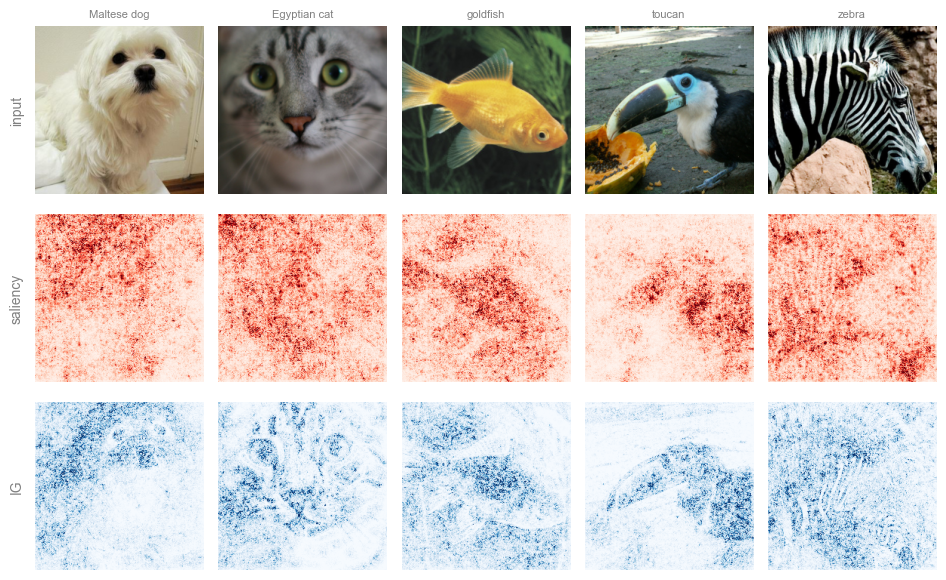

In [72]:
def saliency_map(model, x, target):
    """x: (C, H, W). Returns (H, W): |gradient|, max over color channels."""
    x = x.clone().detach().requires_grad_(True)  # gradients on pixels
    model(x.unsqueeze(0))[0, target].backward()             # one backward pass
    # .amax(0): saliency values are |gradient| >= 0, so keep the strongest-responding
    # channel per pixel (a magnitude -- nothing is conserved, so we do not add channels)
    return x.grad.abs().amax(0).cpu()                       # channel max -> 2D


def integrated_gradients_img(model, x, target, baseline=None, steps=64):
    """x: (C, H, W). Returns (H, W): signed IG, summed over color channels.

    Same batched recipe as the `integrated_gradients` function from earlier,
    just wrapped for images: all `steps` path points go through the model in
    one pass, and the result is summed over color channels.
    """
    if baseline is None:
        baseline = torch.zeros_like(x)           # blank image = "no signal"
    alphas = torch.linspace(0, 1, steps + 1)[:-1] + 0.5 / steps
    # all path points stacked into one batch: (steps, C, H, W)
    path = (baseline + alphas[:, None, None, None] * (x - baseline)).requires_grad_(True)
    model(path)[:, target].sum().backward()      # one backward pass fills path.grad
    grads = path.grad
    # displacement x mean path gradient, then .sum(0) over channels -> 2D signed map.
    # We SUM (not max) because IG is signed and additive: summing keeps each pixel's
    # total contribution and preserves completeness (attributions sum to F(x) - F(x')).
    return ((x - baseline) * grads.mean(0)).sum(0).detach().cpu()


# ---- compute both attributions for every example image --------------
sal_maps = [saliency_map(imagenet_model, img, p) for img, p in zip(imagenet_examples, imagenet_preds)]
ig_maps = [integrated_gradients_img(imagenet_model, img, p, steps=IMAGENET_IG_STEPS)
           for img, p in zip(imagenet_examples, imagenet_preds)]

# ---- 3-row grid: input / saliency / IG ------------------------------------
fig, axes = plt.subplots(3, len(imagenet_examples), figsize=(1.9 * len(imagenet_examples), 6))
for j in range(len(imagenet_examples)):
    im, cmap = imagenet_display_img(imagenet_examples[j])
    axes[0, j].imshow(im, cmap=cmap)
    axes[0, j].set_title(IMAGENET_CLASS_NAMES[imagenet_preds[j]][:16], fontsize=8)
    for r, amap, cmap_a in [(1, sal_maps[j], "Reds"),
                            (2, ig_maps[j].abs(), "Blues")]:
        # sharp contrast: saturate the colormap at the 99th percentile,
        # so everything with real attribution shows up DARK
        vmax = torch.quantile(amap.flatten(), 0.99)
        axes[r, j].imshow(amap, cmap=cmap_a, vmin=0, vmax=vmax)
    for r in range(3):
        axes[r, j].axis("off")
for r, label in enumerate(["input", "saliency", "IG"]):
    axes[r, 0].text(-0.15, 0.5, label, transform=axes[r, 0].transAxes,
                    rotation=90, va="center", fontsize=10)
plt.tight_layout()
plt.show()

<div class="alert alert-danger" role="alert" style="border-radius: 8px; padding: 10px;">

<b>[End of solution]</b>

</div>


## Smoothing IG with a Noise Tunnel

Attributions can be visually noisy or hyper-sensitive to tiny input artifacts. Fix: compute **IG** and smooth it with a **Noise Tunnel**.

The process:
1. Add standard Gaussian noise to the input image.
2. Repeat $N$ times (`nt_samples=10` in our example) to get a batch of noisy variants.
3. Compute IG attributions for every noisy sample.
4. Aggregate by taking the **mean of the squared attributions**, then a final square root, purely for display.

$$\mathrm{NT}_i(x) = \frac{1}{N} \sum_{n=1}^{N} \mathrm{IG}_i \big(x + \varepsilon_n \big)^2, \qquad \varepsilon_n \sim \mathcal{N}(0, 1), \quad N=10$$

That's what `ig_noise_tunnel` computes. We then take the RMS, $\sqrt{\mathrm{NT}_i(x)}$, to rescale it for visualisation.

**Why squaring works:** attributions that **survive the noise** are robust, meaningful structure; random pixel jitter averages away. Squaring makes the map positive and emphasizes the strongest, most reliable signals.


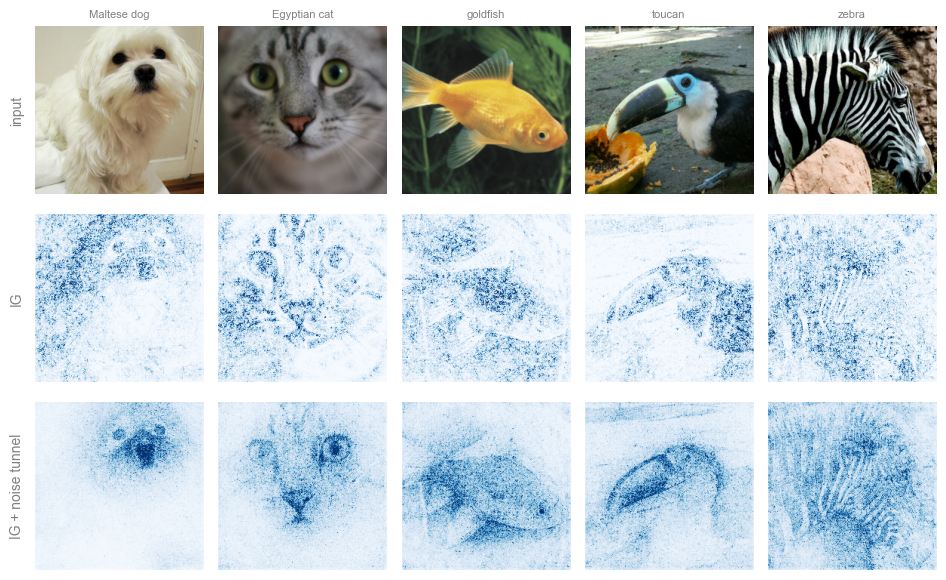

In [73]:
#-------------------------------------------------------------------------------------

def ig_noise_tunnel(model, x, target, nt_samples=10, stdev=None, noise_frac=0.3, steps=32):
    """Noise tunnel over IG with the `smoothgrad_sq` rule:
    root-mean-square of the SQUARED IG maps across nt_samples noisy copies of x.

    stdev=None scales the noise to a FRACTION of the image's own dynamic range
    (`noise_frac * (max - min)`) rather than a fixed absolute value.

    The final sqrt matters: squaring then averaging shrinks small values far more
    than large ones (0.2^2 is 25x smaller than 1.0^2, not just 5x), so without it
    faint-but-real attribution can vanish next to strong peaks once displayed.
    """
    if stdev is None:
        stdev = noise_frac * (x.max() - x.min()).item()

    attrs = []

    for _ in range(nt_samples):

        noisy = x + stdev * torch.randn_like(x)      # gaussian noise, sd = stdev

        # use the shared integrated_gradients; .sum(0) collapses the color channel -> 2D
        ig = integrated_gradients(model, noisy, target=target, steps=steps).sum(0)

        attrs.append(ig ** 2) # compiling attributions for each noise case

    return torch.stack(attrs).mean(0)

#-------------------------------------------------------------------------------------



# NOTE: this runs nt_samples x IG per image -- with IMAGENET on CPU it can
# take a few minutes; reduce nt_samples if pressed for time.
ig_maps = [integrated_gradients(imagenet_model, img, target=p, steps=IMAGENET_IG_STEPS).sum(0).detach().cpu()
           for img, p in zip(imagenet_examples, imagenet_preds)]
nt_maps = [ig_noise_tunnel(imagenet_model, img, p, nt_samples=10, steps=IMAGENET_IG_STEPS)
           for img, p in zip(imagenet_examples, imagenet_preds)]

fig, axes = plt.subplots(3, len(imagenet_examples), figsize=(1.9 * len(imagenet_examples), 6))
for j in range(len(imagenet_examples)):
    im, cmap = imagenet_display_img(imagenet_examples[j])
    axes[0, j].imshow(im, cmap=cmap)
    axes[0, j].set_title(IMAGENET_CLASS_NAMES[imagenet_preds[j]][:16], fontsize=8)
    for r, amap in [(1, ig_maps[j].abs()), (2, nt_maps[j].sqrt())]:
        vmax = torch.quantile(amap.flatten(), 0.99)  # sharp contrast
        axes[r, j].imshow(amap, cmap="Blues", vmin=0, vmax=vmax)
    for r in range(3):
        axes[r, j].axis("off")
for r, label in enumerate(["input", "IG", "IG + noise tunnel"]):
    axes[r, 0].text(-0.15, 0.5, label, transform=axes[r, 0].transAxes,
                    rotation=90, va="center", fontsize=10)
plt.tight_layout()
plt.show()

# **Mechanistic Explainability/Interpretability:** Finding the _Circuits_

So far we attributed predictions to the **inputs**: saliency and IG tell us *where the model looked*.

**Mechanistic explainability** instead explains the prediction through the network's **internal structure**. Its central object: the **circuit** — *the minimal subnetwork of features and weights responsible for a specific behavior* (Olah et al., 2020).


<img src="images/memes/mechanistic.png" style="display:block; margin-left:auto; margin-right:auto;">


## How a Circuit Forms, Layer by Layer

Think of a network as **layers of feature detectors wired together**. We can trace responsibility for a prediction backwards through its internal components:

*   **The Final Layer (Direct Translation):**
    The output logit is literally a linear weighted sum of the previous layer's activations:

    $$ \mathrm{logit}_c = \sum_i W_{c,i} \, a_i + b_c $$

    $\rightarrow$ Unit $i$ contributes **exactly** $W_{c,i} \, a_i$ — just read off the addends. The largest-valued units are the circuit's founding members.

*   **One Layer Deeper (Activation $\times$ Gradient):**
    Deeper units feed into the logit through weights, ReLUs, and pooling, so the relationship is no longer linear. We estimate each channel's contribution as **Activation $\times$ Gradient**: *(how active it was)* $\times$ *(how much the logit reacts to it)*.

*   **...And So On, Backwards:**
    Repeating this stage by stage traces responsibility from the logit back through the dense layers and convolutions, all the way to the pixels — meeting the input attributions from earlier in this notebook.

<u>**Putting It Together**</u>

A **circuit** is the subgraph left when you keep only the top-contributing units at each stage. Members *connect naturally across layers*: a late-stage unit scores highly precisely **because** it reads from strongly-contributing earlier units. The wiring between members is where the actual computation happens.

<u>**Which neurons matter, layer by layer?**</u>

Before drawing the full circuit, let's find its pieces by hand: for one **category**, average `gradient × activation` over several of its test images to rank each layer's neurons by how much they support that class in general — a **class-general** circuit. A quick experiment on MNIST:

In [74]:
# ---- top neurons per layer, for ONE example image -----------------------

EXAMPLE_IDX = 0                                 # pick one test image to interrogate
img, CATEGORY = test_ds[EXAMPLE_IDX]
img = img.unsqueeze(0)               # add a batch dim of size 1: (1, 1, 28, 28)

# Step 1: forward pass, keeping each layer's ACTIVATIONS (how much each
# neuron fired) so we can inspect them after the fact.
a1 = F.max_pool2d(F.relu(model.conv1(img)), 2)  # (1, 32, 14, 14) -- conv1 activations
a2 = F.max_pool2d(F.relu(model.conv2(a1)), 2)   # (1, 64, 7, 7)   -- conv2 activations
a3 = F.relu(model.fc1(a2.flatten(1)))           # (1, 256)        -- fc1 activations
a4 = F.relu(model.fc2(a3))                      # (1, 128)        -- fc2 activations
logits = model.fc3(a4)                          # (1, 10)         -- final class scores
stages = [("conv1", a1), ("conv2", a2), ("fc1", a3), ("fc2", a4)]

# Step 2: backward pass FROM the true class's score, so autograd tells us
# the GRADIENT of that score with respect to every activation we kept.
class_score = logits[0, CATEGORY]
grads = torch.autograd.grad(class_score, [t for _, t in stages])

# Step 3: importance = activation x gradient.
#   - activation alone: "did this neuron fire?"
#   - gradient alone:   "would the class score change if it fired more?"
#   - multiplied:       "did it fire, AND did that firing matter?"
print(f"top neurons per layer for category '{CLASS_NAMES[CATEGORY]}' (one image, idx {EXAMPLE_IDX}):")
top_by_layer = {}                                       # name -> top-5 neuron indices
for (name, activation), gradient in zip(stages, grads):
    importance = activation * gradient                  # same shape as the activation
    if importance.dim() == 4:                           # conv layer: (1, C, H, W)
        importance = importance.sum(dim=(-2, -1))        # collapse each channel's map to one number
    importance = importance[0].detach().cpu()             # drop the batch dim -> (C,)

    top5 = importance.abs().topk(5).indices.tolist()
    top_by_layer[name] = top5
    print(f"  {name:6s}: neurons {top5}")


top neurons per layer for category '7' (one image, idx 0):
  conv1 : neurons [4, 21, 18, 14, 3]
  conv2 : neurons [49, 45, 52, 1, 21]
  fc1   : neurons [180, 152, 32, 112, 126]
  fc2   : neurons [13, 106, 80, 88, 50]


<u>**How much accuracy survives, layer by layer?**</u>

The top-5 lists above are a *look*, not a *test*. Turn the same `|gradient x activation|` ranking into a sweep: per layer, keep only the top **fraction** of neurons and zero out the rest, then measure test accuracy as that fraction goes from 0 to 1. A curve that rises steeply at small fractions then flattens says most of the accuracy lives in a small, identifiable subset of each layer. This tests the ranking above rather than just showing it: if the top-ranked units genuinely drove the predictions, keeping only them should preserve most of the accuracy.

**A caveat on "fraction kept."** The fraction is a knob we chose to *demonstrate* that a small subnetwork can carry most of the accuracy — not a claim that this ranking finds the smallest or "correct" circuit. `|gradient x activation|` is one reasonable importance criterion among several; a different one could select a different subnetwork. **Certified circuits** use a stricter criterion: instead of a fraction, they keep only units provably stable under changes in the scoring data.


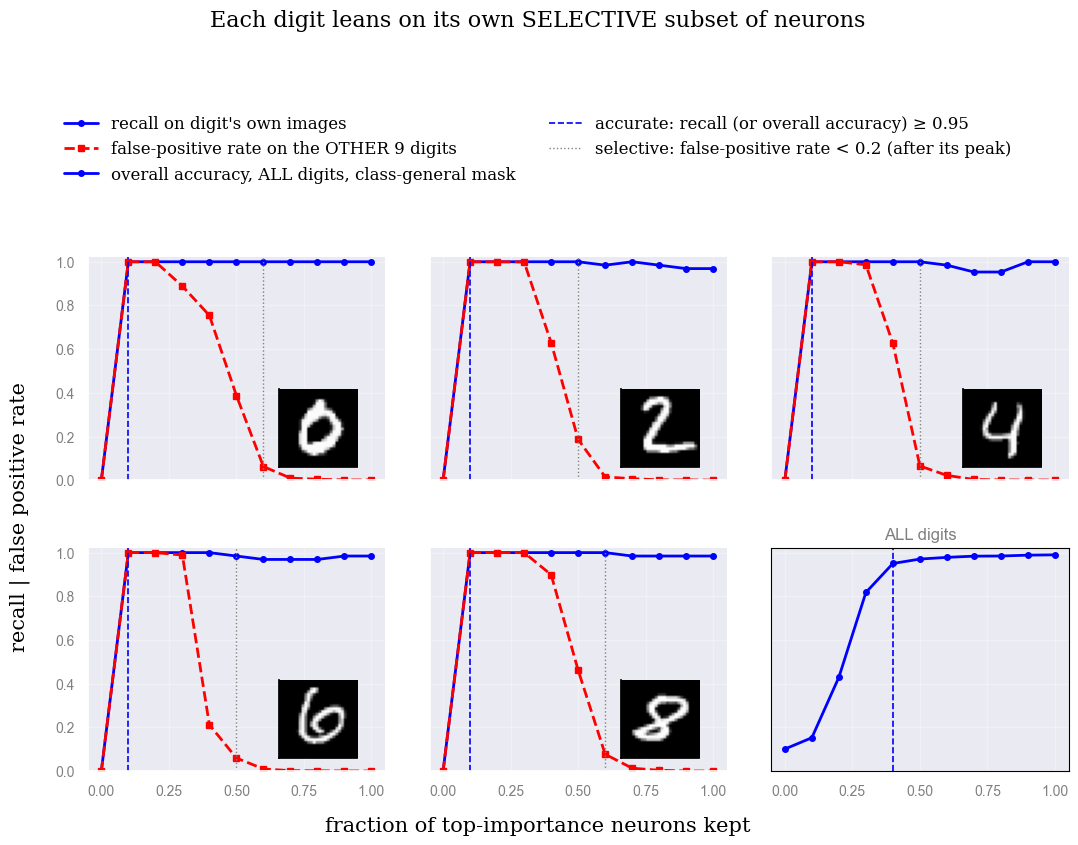

In [75]:
# ---- selectivity vs. fraction of top-importance neurons kept, PER DIGIT --
# Rank neurons separately for EACH digit (its own |gradient x activation|,
# averaged over that digit's own test images), then ablate everyone else and
# measure TWO things, not just one: recall on digit d's OWN images (does the
# ablated network still call a d a d?) AND the false-positive rate on the
# OTHER 9 digits' images run through that SAME digit-d mask (does the ablated
# network wrongly call something ELSE a d too?). Recall alone can't tell a
# genuinely digit-specific circuit apart from a network that has simply
# degenerated into "always predict d" -- a trivial classifier would ace
# recall while failing the false-positive check badly. Only a curve where
# recall stays high AND the false-positive rate stays low earns the claim
# that each digit leans on its OWN, SELECTIVE subset of neurons.
def forward_ablated(x, masks):
    a1 = F.max_pool2d(F.relu(model.conv1(x)), 2) * masks["conv1"][None, :, None, None]
    a2 = F.max_pool2d(F.relu(model.conv2(a1)), 2) * masks["conv2"][None, :, None, None]
    a3 = F.relu(model.fc1(a2.flatten(1))) * masks["fc1"][None, :]
    a4 = F.relu(model.fc2(a3)) * masks["fc2"][None, :]
    return model.fc3(a4)

def make_masks(layer_scores, keep_fraction):
    """Per layer, keep only the top `keep_fraction` of units (out of ALL
    units in that layer) by importance; zero out the rest."""
    masks = {}
    for name, scores in layer_scores.items():
        n = len(scores)
        n_keep = int(round(keep_fraction * n))
        keep_idx = scores.topk(n_keep).indices if n_keep > 0 else torch.tensor([], dtype=torch.long)
        m = torch.zeros(n)
        m[keep_idx] = 1.0
        masks[name] = m
    return masks

fractions = torch.linspace(0.0, 1.0, 11)
digits_to_show = [0, 2, 4, 6, 8]                # 5 per-digit panels + 1 "ALL digits" panel = 2x3
fig, axes = plt.subplots(2, 3, figsize=(11, 6.5), sharex=True, sharey=True)

with plt.rc_context({"font.family": "serif", "font.size": 13,
                      "text.color": "black", "axes.labelcolor": "black",
                      "xtick.color": "black", "ytick.color": "black",
                      "xtick.labelsize": 13, "ytick.labelsize": 13}):
    line_recall = line_fp = line_selective_thresh = line_recall_thresh = None
    for panel, digit in enumerate(digits_to_show):
        # ---- this digit's OWN importance ranking, from its OWN images ----
        idx = [i for i in range(len(test_ds)) if test_ds[i][1] == digit][:64]
        other_idx = [i for i in range(len(test_ds)) if test_ds[i][1] != digit]
        imgs_d = torch.stack([test_ds[i][0] for i in idx])
        imgs_other = torch.stack([test_ds[i][0] for i in other_idx])

        a1 = F.max_pool2d(F.relu(model.conv1(imgs_d)), 2)
        a2 = F.max_pool2d(F.relu(model.conv2(a1)), 2)
        a3 = F.relu(model.fc1(a2.flatten(1)))
        a4 = F.relu(model.fc2(a3))
        logits_d = model.fc3(a4)
        stages_d = [("conv1", a1), ("conv2", a2), ("fc1", a3), ("fc2", a4)]

        grads_d = torch.autograd.grad(logits_d[:, digit].sum(), [t for _, t in stages_d])
        layer_scores = {}
        for (name, t), g in zip(stages_d, grads_d):
            s = (g * t)
            s = s.sum((-2, -1)) if s.dim() == 4 else s
            layer_scores[name] = s.mean(0).detach().abs().cpu()

        # ---- ablate everyone except the top fraction, per layer, and
        # measure recall (own images) AND false-positive rate (everyone else's
        # images, through the SAME mask) ------------------------------------
        recalls, false_pos = [], []
        with torch.no_grad():
            for frac in fractions:
                masks = make_masks(layer_scores, frac.item())
                digit_preds = forward_ablated(imgs_d, masks).argmax(1)
                other_preds = forward_ablated(imgs_other, masks).argmax(1)
                recalls.append((digit_preds == digit).float().mean().item())
                false_pos.append((other_preds == digit).float().mean().item())

        ax = axes.flat[panel]
        line_recall, = ax.plot(fractions.numpy(), recalls, marker="o", ms=4,
                                color="blue")
        line_fp, = ax.plot(fractions.numpy(), false_pos, marker="s", ms=4,
                            ls="--", color="red")
        # reference line: false-positive rate typically SPIKES up first (too
        # few surviving units -> bias-dominated, near-constant predictions)
        # before settling down as more units are kept. Find where it dips
        # below 0.2 AFTER that peak -- not the first low point, which could
        # trivially be x=0, before the spike has even happened.
        peak = false_pos.index(max(false_pos))
        after_peak = [f for f, fp in zip(fractions.tolist()[peak:], false_pos[peak:]) if fp < 0.2]
        if after_peak:
            line_selective_thresh = ax.axvline(after_peak[0], color="gray", ls=":", lw=1.0)

        # reference line: fraction where recall alone first reaches "basically
        # 1" (>= 0.95) -- pixels can be enough to predict the digit correctly
        # well BEFORE the surviving units are actually SELECTIVE for it (that
        # is the dotted line above); this dashed line marks that earlier,
        # weaker bar.
        high_recall = [f for f, r in zip(fractions.tolist(), recalls) if r >= 0.95]
        if high_recall:
            line_recall_thresh = ax.axvline(high_recall[0], color="blue", ls="--", lw=1.2)
        ax.set_ylim(0, 1.02)
        ax.set_box_aspect(0.75)                          # short and wide, not square

        # small thumbnail of one example of this digit, bottom-right corner
        # -- stands in for the removed "digit N" subtitle
        thumb = imgs_d[0].squeeze().cpu()
        inset = ax.inset_axes([0.60, 0.06, 0.35, 0.35])
        inset.imshow(thumb, cmap="gray")
        inset.set_xticks([])
        inset.set_yticks([])
        for spine in inset.spines.values():
            spine.set_edgecolor("black")

    # ---- 6th panel: ALL digits at once -- does the model even need a
    # digit-specific mask, or does keeping just any top-importance subset
    # (ranked class-generally, not per-digit) preserve WHOLE-test-set
    # accuracy? A single line: with all 10 classes in play there is no
    # "other" group left to define a false-positive rate against. --------
    imp_idx = list(range(0, len(test_ds), max(1, len(test_ds) // 2000)))[:2000]
    imp_imgs = torch.stack([test_ds[i][0] for i in imp_idx])

    a1 = F.max_pool2d(F.relu(model.conv1(imp_imgs)), 2)
    a2 = F.max_pool2d(F.relu(model.conv2(a1)), 2)
    a3 = F.relu(model.fc1(a2.flatten(1)))
    a4 = F.relu(model.fc2(a3))
    logits_imp = model.fc3(a4)
    imp_stages = [("conv1", a1), ("conv2", a2), ("fc1", a3), ("fc2", a4)]

    target_logits = logits_imp.gather(1, logits_imp.argmax(1, keepdim=True)).squeeze(1)
    imp_grads = torch.autograd.grad(target_logits.sum(), [t for _, t in imp_stages])
    layer_scores_all = {}
    for (name, t), g in zip(imp_stages, imp_grads):
        s = (g * t)
        s = s.sum((-2, -1)) if s.dim() == 4 else s
        layer_scores_all[name] = s.mean(0).detach().abs().cpu()

    all_accuracies = []
    with torch.no_grad():
        for frac in fractions:
            masks = make_masks(layer_scores_all, frac.item())
            correct = 0
            for xb, yb in test_dl:
                correct += (forward_ablated(xb, masks).argmax(1) == yb).sum().item()
            all_accuracies.append(correct / len(test_ds))

    ax_all = axes.flat[5]
    line_all, = ax_all.plot(fractions.numpy(), all_accuracies, marker="o", ms=4,
                             color="blue")
    # reference line: first fraction where overall accuracy climbs above
    # 0.95 -- dashed, same style as the per-digit recall-threshold line
    above = [f for f, acc in zip(fractions.tolist(), all_accuracies) if acc > 0.95]
    if above:
        ax_all.axvline(above[0], color="blue", ls="--", lw=1.2)
    ax_all.set_ylim(0, 1.02)
    ax_all.set_box_aspect(0.75)
    ax_all.set_title("ALL digits", fontsize=12)
    for spine in ax_all.spines.values():          # thin border, ONLY on this panel
        spine.set_visible(True)
        spine.set_edgecolor("black")
        spine.set_linewidth(0.8)

    fig.legend([line_recall, line_fp, line_all, line_recall_thresh, line_selective_thresh],
               ["recall on digit's own images", "false-positive rate on the OTHER 9 digits",
                "overall accuracy, ALL digits, class-general mask",
                "accurate: recall (or overall accuracy) ≥ 0.95",
                "selective: false-positive rate < 0.2 (after its peak)"],
               loc="upper center", bbox_to_anchor=(0.5, 1.14), ncol=2,
               fontsize=12, frameon=False, labelcolor="black")
    fig.supxlabel("fraction of top-importance neurons kept", fontsize=15, color="black")
    fig.supylabel("recall | false positive rate", fontsize=15, color="black")
    fig.suptitle("Each digit leans on its own SELECTIVE subset of neurons", y=1.28,
                 fontsize=16, color="black")
    plt.tight_layout()
    fig.subplots_adjust(hspace=0.25, wspace=0.15)          # tighter spacing between rows/cols
    plt.show()

<u>**Drawing the circuit**</u>

One node per channel/unit, **circuit members highlighted**, everything else greyed out. Early (convolutional) members are drawn as their **activation map on this input** — you see *where* each filter fires. Frame/edge colors give the **sign** (red supports the class, blue opposes).

Scores are gradient $\times$ activation: **exact** for the last stage (the logit is linear in it), a first-order estimate earlier. Edges between hidden stages show *membership*; edges into the logit are the **exact** last-layer contributions.

This is the **instance-specific** circuit for one image — contrast it with the **class-general** top neurons found above by averaging over many images: see which neurons reappear here.

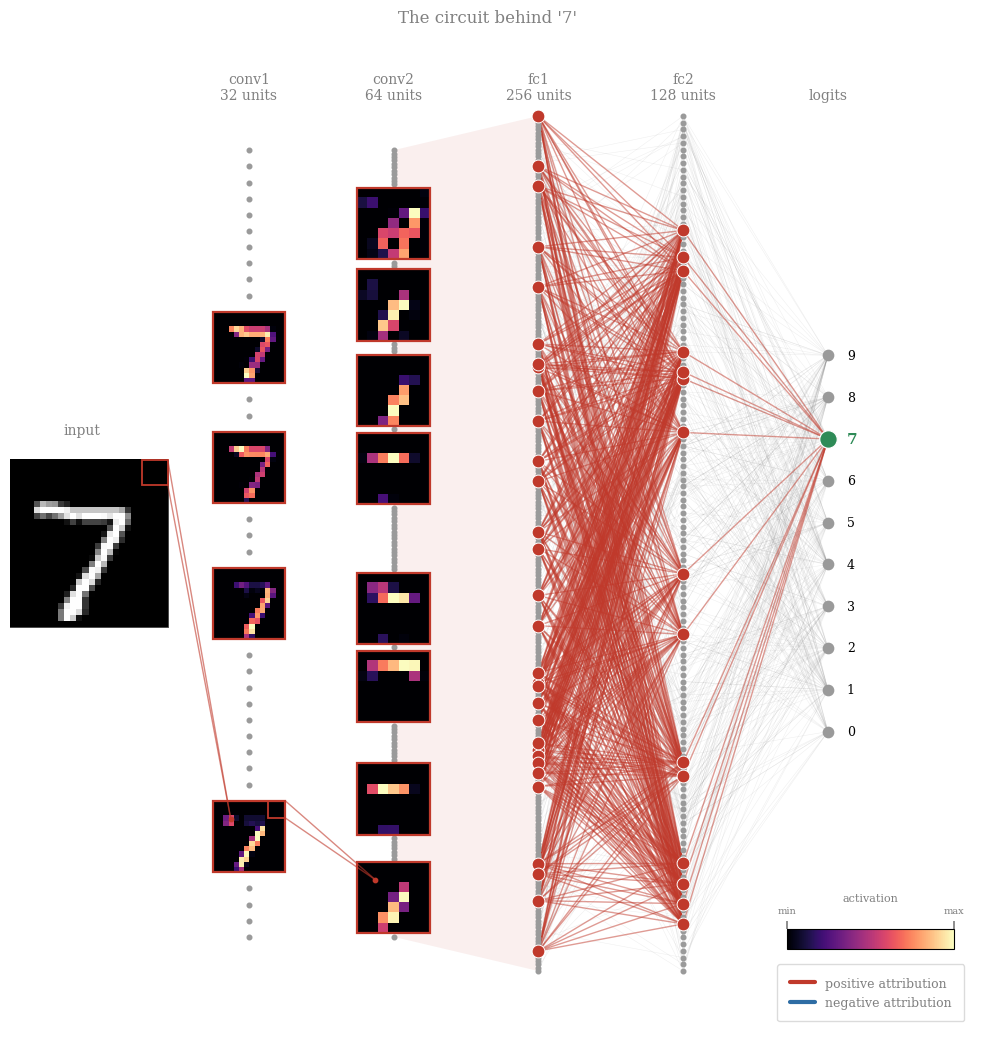

In [76]:
from helpers import draw_circuit


# =====================================================================
# use it: the circuit diagram for ONE image, purely for a LOOK at what a
# sub-circuit looks like -- play with these two knobs freely:
# =====================================================================
DIGIT = 7        # <- which digit's circuit to draw (0-9)
FRACTION = 0.12  # <- fraction of units kept per layer (top-k by |score|)

img_idx = next(i for i in range(len(test_ds)) if test_ds[i][1] == DIGIT)
img = test_ds[img_idx][0]
x = img.unsqueeze(0)
with torch.no_grad():
    p = model(x).argmax().item()

# forward pass, keeping the intermediate activations (so autograd can give
# us gradients w.r.t. each stage)
a1 = F.max_pool2d(F.relu(model.conv1(x)), 2)     # (1, 32, 14, 14)
a2 = F.max_pool2d(F.relu(model.conv2(a1)), 2)    # (1, 64, 7, 7)
a3 = F.relu(model.fc1(a2.flatten(1)))            # (1, 256)
a4 = F.relu(model.fc2(a3))                       # (1, 128)
logits_vec = model.fc3(a4)[0]                    # (10,)
stages = [("conv1", a1), ("conv2", a2), ("fc1", a3), ("fc2", a4)]
top_k = [max(1, round(FRACTION * a.shape[1])) for _, a in stages]

tops = draw_circuit(stages, logits_vec, p, CLASS_NAMES, img,
                    input_display=display_img(img), top_k=top_k)


<div style="border-left: 4px solid #4CAF50; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #e8f5e9; color: #1a1a1a; box-sizing: border-box; max-width: 100%; overflow-wrap: break-word;">

**NOTE:** Read left to right: the faint grey mesh is everything the network *could* use; the red thread is what it *did* use — early feature maps firing on the relevant structure, combined into later units, funneled (exactly, at the last step) into the class logit.

Caution: *which* units make the circuit depends on the data used to score them. **Certified circuits** (Anani et al. 2026) keep only members provably **stable** under changes of that data — the unstable rest are often spurious cues.

</div>

# **Exercise**: _Astrophysical Case Study_: Galaxy Morphology

**Morphology** is one of the oldest observables in extragalactic astronomy. Hubble's sequence separates smooth, pressure-supported **ellipticals** from rotation-supported **spirals**; **bars** mark disk instabilities that funnel gas toward the center; **mergers** capture chaotic gravitational interactions between systems. Morphology correlates with color, star-formation history, and environment — measuring it *at survey scale* is real science.

Modern surveys (SDSS, Euclid, LSST) deliver far more galaxies than humans can inspect. Galaxy Zoo answered with citizen science; today we increasingly use CNNs — which brings us back to this lecture's point: a classifier used for science needs **evidence it classifies on morphology** (arms, bars, tidal tails, light profiles), not artifacts or background clutter.

We use generated **toy galaxies**, so the lab runs anywhere with no download and full control over ground truth — six classes:

- **elliptical** — smooth Sersic light profile, random elongation, subtle asymmetry
- **spiral** — bright bulge, disk, and 2–4 sweeping arms
- **barred spiral** — central bar with two unwinding arms growing from its ends
- **merger** — interacting pairs (spiral-spiral, elliptical-elliptical, spiral-barred) with tidal bridges, shared envelopes, disrupted tails
- **edge-on** — a disk galaxy seen edge-on: thin, elongated profile with a central bulge, arm structure hidden by viewing angle
- **irregular** — clumpy, asymmetric Magellanic-type systems, patchy star-forming knots, no clear rotational symmetry

Each has randomized orientation, inclination, bulge size, and zoom, embedded in a field with observation noise, faint point-source stars, and satellite galaxies.

$\rightarrow$ The guiding question throughout: **does the network use the intrinsic morphological features (arms, bar, tidal interactions)?**


<div style="border-left: 4px solid #4CAF50; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #e8f5e9; color: #1a1a1a; box-sizing: border-box; max-width: 100%; overflow-wrap: break-word;">

**NOTE:** These are **not physics simulations** — no equations of motion, no gas dynamics or radiative transfer, nothing evolves forward in time. But they are **not arbitrary textures** either: the light profiles use real structural-astronomy forms — **Sersic profiles** for bulges/ellipticals, the standard **exponential-disk + sech² dust-lane** model for edge-on galaxies, and **logarithmic-spiral** winding for arms (including bifurcating branches, as seen in real grand-design spirals, and faint-skewed star-forming knots). Merger features follow real physics too: **differential tidal forces** stretch near-side material into a bridge and fling far-side material into a tail, with companion size/brightness scaled by mass. What's idealised is the *assembly* — parameters are hand-tuned and randomised to look right, not evolved forward from a physical system. Good enough to check by eye whether an explainability method finds the right features, before trusting it on real survey data. Generator code: [github.com/arnablahiry/galaxy-morphology-textures](https://github.com/arnablahiry/galaxy-morphology-textures).

</div>


<img src="images/galaxy_morphology_grid.png" width=900 style="display:block; margin-left:auto; margin-right:auto;">

<table><tr><td width=900><center><br>
    Example synthetic galaxies from each of the 6 morphological classes used in this notebook.<br>
<br></center></td></tr></table>


In [77]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F


class GalaxyCNN(nn.Module):
    def __init__(self, img_size=64, n_classes=6):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 64, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 128, 3, padding=1)    # in_channels matches conv1's OUTPUT (64)
        self.bn2 = nn.BatchNorm2d(128)
        self.conv3 = nn.Conv2d(128, 256, 3, padding=1)   # in_channels matches conv2's OUTPUT (128)
        self.bn3 = nn.BatchNorm2d(256)
        feat_size = img_size // 8                    # three 2x2 max-pools
        self.fc1 = nn.Linear(256 * feat_size * feat_size, 128)
        self.fc1b = nn.Linear(128, 64)                # extra hidden layer
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(64, n_classes)

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.bn1(self.conv1(x))), 2)
        x = F.max_pool2d(F.relu(self.bn2(self.conv2(x))), 2)
        x = F.max_pool2d(F.relu(self.bn3(self.conv3(x))), 2)
        x = F.relu(self.fc1(x.flatten(1)))
        x = F.relu(self.fc1b(x))
        x = self.dropout(x)
        return self.fc2(x)



CLASSES = ["elliptical", "spiral", "barred spiral", "merger",
           "edge-on", "irregular"]

# ---- load the held-out test split from disk, just to read its image size --
GAL_DATA_DIR = "data/gal_data"
print(f"loading gal_Xte from {GAL_DATA_DIR}/ (only needed for its image size)...")
gal_Xte = torch.from_numpy(np.load(os.path.join(GAL_DATA_DIR, "gal_Xte.npy")))
print(f"  gal_Xte: {gal_Xte.shape}")

GAL_MODEL_PATH = "models/gal_model_best.pt"

print("building GalaxyCNN...")
gal_model = GalaxyCNN(img_size=gal_Xte.shape[-1], n_classes=len(CLASSES))

n_params = sum(p.numel() for p in gal_model.parameters())
n_trainable = sum(p.numel() for p in gal_model.parameters() if p.requires_grad)
print(f"  {n_params:,} parameters total ({n_trainable:,} trainable)")

print(f"loading pretrained weights from {GAL_MODEL_PATH}...")
gal_model.load_state_dict(torch.load(GAL_MODEL_PATH, map_location="cpu"))
gal_model.eval()
print("done -- gal_model is ready for inference.")


loading gal_Xte from data/gal_data/ (only needed for its image size)...
  gal_Xte: torch.Size([1500, 1, 128, 128])
building GalaxyCNN...
  8,767,942 parameters total (8,767,942 trainable)
loading pretrained weights from models/gal_model_best.pt...
done -- gal_model is ready for inference.


<img src="images/galCNN_arch.png" style="display:block; margin-left:auto; margin-right:auto;">

<table><tr><td width=800><center><br>
    Architecture of the Convolutional Neural Network (CNN) used to classify the synthetic galaxy images.<br>
<br></center></td></tr></table>


## Saliency and integrated gradient attributions

Same recipes as the MNIST section, now on galaxies. Saliency is one backward pass; IG integrates gradients from a zero baseline $=$ *"empty sky"* (we check **completeness** first); the noise tunnel averages **squared IG** over noisy copies (`smoothgrad_sq` — the textbook definition has no sqrt) with one extra square root only so it plots on the same scale as plain IG. Structure that survives pixel-level jitter remains, just rescaled for a fair comparison. For the spiral and barred spiral maps, attribution should trace the **arms** and the **bar**, not the sky.

In [78]:
# ---- always analyze the actual SAVED best checkpoint, not whatever
# happens to be in memory (which could be stale/mid-training if cells were
# re-run out of order) -----------------------------------------------------
#
# Requires from earlier cells: `gal_model` already built and its pretrained
# weights loaded (see the GalaxyCNN cell above). Everything
# else needed here -- imports, the class list, and the small plotting
# helper -- is self-contained below.

import os
import torch
import matplotlib.pyplot as plt
import numpy as np


def clean_axis(ax):
    """No ticks, but keep a thin black frame around the subplot."""
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5)
        spine.set_color("black")


CLASSES = ["elliptical", "spiral", "barred spiral", "merger",
           "edge-on", "irregular"]

GAL_DATA_DIR = "data/gal_data"

# ---- load the fixed 5-example-per-class set saved by a previous run ------
ATTR_EXAMPLES_DIR = os.path.join(GAL_DATA_DIR, "attribution_examples")
print(f"loading saved attribution examples from {ATTR_EXAMPLES_DIR}/...")
example_images, example_true = {}, {}
for cls_name in CLASSES:
    class_tag = cls_name.replace(" ", "_")
    example_images[cls_name] = torch.from_numpy(
        np.load(os.path.join(ATTR_EXAMPLES_DIR, f"{class_tag}_images.npy")))
    example_true[cls_name] = np.load(
        os.path.join(ATTR_EXAMPLES_DIR, f"{class_tag}_true_labels.npy"))
print(f"  loaded {sum(len(v) for v in example_images.values())} images "
      f"across {len(CLASSES)} classes")


loading saved attribution examples from data/gal_data/attribution_examples/...
  loaded 30 images across 6 classes


<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4>**Exercise — Saliency, IG, and Noise Tunnel on Galaxy Morphology [15 min]**</font>

**Objective:** Show once more that saliency/IG/noise-tunnel are model-agnostic: reuse the MNIST/ImageNet recipes on `gal_model` and the galaxy images, then control what gets displayed.

**Task:** Fill in the blanks to implement `gal_saliency`, `gal_ig`, and `gal_ig_noise_tunnel` for `gal_model`. Loading the examples, the completeness check, and plotting are already done.

1. `gal_saliency(model, x, target)`: one backward pass, the absolute gradient of the target logit w.r.t. the input pixels (single-channel images, so no color-channel reduction needed).
2. `gal_ig(model, x, target, steps=64)`: a midpoint Riemann sum along the straight-line path from `baseline` ("empty sky" — an all-zero image) to `x`, scaled by `(x - baseline)`.
3. `gal_ig_noise_tunnel(model, x, target, nt_samples=10, stdev=None, steps=64)`: run `gal_ig` on `nt_samples` noisy copies of `x`, square each map, average, then square-root (`smoothgrad_sq`).
4. Once it runs, check the completeness printout above matches (`sum(IG) ≈ F(x) - F(baseline)`) before trusting the maps.
5. Edit `CATEGORIES_TO_SHOW` to control which of the 6 classes get plotted below — try `["spiral"]`, then `["elliptical", "spiral"]`, then all of `CLASSES`.

**Data:** The 5 saved example images per class (6 classes x 5 images) loaded above.

</div>

In [79]:
def gal_saliency(model, x, target):
    """Vanilla saliency: |gradient of the target logit w.r.t. the input|."""
    ...



def gal_ig(model, x, target, steps=64):
    """Integrated Gradients: midpoint Riemann sum along baseline -> x."""
    ...


def gal_ig_noise_tunnel(model, x, target, nt_samples=10, stdev=None, steps=64):
    """Noise tunnel over gal_ig with the `smoothgrad_sq` rule:
    mean of the SQUARED IG maps across nt_samples noisy copies of x.

    stdev=None scales the noise to the image itself (0.5 * x.std()) -- the toy
    galaxies live on a 0-3 scale with std ~0.27, so a fixed stdev=1.0 would drown the signal and make every map look hazy.
    """

    ...


# ---- completeness check: sum(IG) should equal F(x) - F(baseline) ---------
print("running the IG completeness check on one example image...")
xg = example_images[CLASSES[0]][0]
with torch.no_grad():
    pg = gal_model(xg.unsqueeze(0)).argmax().item()
ig_g = gal_ig(gal_model, xg, pg, steps=256)
with torch.no_grad():
    delta = (gal_model(xg.unsqueeze(0))[0, pg]
             - gal_model(torch.zeros_like(xg).unsqueeze(0))[0, pg]).item()
print(f"  sum(IG) = {ig_g.sum():.3f}   F(x) - F(baseline) = {delta:.3f}   "
      f"(these should match -- that's completeness)")

# ---- which classes to actually print below -- edit this list -------------
CATEGORIES_TO_SHOW = ["spiral"]        # e.g. ["elliptical", "spiral"] for two,
                                        # or CLASSES for all six

# ---- for each requested class: the 5 saved example images x (input / IG / IG+noise tunnel) ----
print(f"generating attribution grids for {len(CATEGORIES_TO_SHOW)} classes, 5 examples each...")
for cls in range(len(CLASSES)):
    cls_name = CLASSES[cls]
    if cls_name not in CATEGORIES_TO_SHOW:
        continue
    imgs = example_images[cls_name]
    true_labels = example_true[cls_name]

    ncols = len(imgs)
    # a dedicated colorbar column (own axis, not carved out of the last image subplot)
    fig, axes = plt.subplots(3, ncols + 1, figsize=(1.7 * ncols + 1.1, 5.6),
                              gridspec_kw={"width_ratios": [1] * ncols + [0.1], "wspace": 0.1})
    img_axes, cbar_axes = axes[:, :ncols], axes[:, ncols]
    row_im = [None, None, None]
    for j in range(ncols):
        xg = imgs[j]
        true_cls = int(true_labels[j])
        with torch.no_grad():
            pg = gal_model(xg.unsqueeze(0)).argmax().item()
        ig_j = gal_ig(gal_model, xg, pg).abs()
        nt_j = gal_ig_noise_tunnel(gal_model, xg, pg, nt_samples=10)

        input_norm = xg.squeeze() / xg.max().clamp(min=1e-8)
        row_im[0] = img_axes[0, j].imshow(input_norm, cmap="gray", vmin=0, vmax=1)
        ax0 = img_axes[0, j]
        ax0.text(0.5, 1.18, f"true: {CLASSES[true_cls]}", transform=ax0.transAxes,
                 ha="center", va="bottom", fontsize=8)
        ax0.text(0.5, 1.05, f"pred: {CLASSES[pg]}", transform=ax0.transAxes,
                 ha="center", va="bottom", fontsize=8,
                 color="darkgreen" if pg == true_cls else "black")
        for r, amap, cmap in [(1, ig_j, "Blues"), (2, nt_j, "Blues")]:
            vmax = torch.quantile(amap.flatten(), 0.99).clamp(min=1e-8)   # contrast stretch
            amap_norm = (amap / vmax).clamp(0, 1)                        # -> [0, 1]
            row_im[r] = img_axes[r, j].imshow(amap_norm, cmap=cmap, vmin=0, vmax=1)
        for r in range(3):
            clean_axis(img_axes[r, j])

    row_labels = ["input", "IG", "IG + noise tunnel"]
    cbar_labels = ["[norm] intensity", "[norm] IG attributions", "[norm] IG attributions"]
    for r, (label, cbar_label) in enumerate(zip(row_labels, cbar_labels)):
        img_axes[r, 0].text(-0.15, 0.5, label, transform=img_axes[r, 0].transAxes,
                            rotation=90, va="center", fontsize=9)
        cbar = fig.colorbar(row_im[r], cax=cbar_axes[r])
        cbar.outline.set_visible(True)
        cbar.outline.set_linewidth(0.8)
        cbar.outline.set_edgecolor("black")
        cbar.set_label(cbar_label, fontsize=7)
        cbar.ax.tick_params(labelsize=6, width=0.8)
    fig.suptitle(CLASSES[cls], fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()

print(f"done.")


running the IG completeness check on one example image...


AttributeError: 'NoneType' object has no attribute 'sum'

<div class="alert alert-danger" role="alert" style="border-radius: 8px; padding: 10px;">

<b>[Solution below]</b>

</div>

running the IG completeness check on one example image...
  sum(IG) = -12.549   F(x) - F(baseline) = -12.541   (these should match -- that's completeness)
generating attribution grids for 1 classes, 5 examples each...


/var/folders/bp/qbk6vrmx3vz8pnjkwdvk9_b40000gn/T/ipykernel_90087/1103176427.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


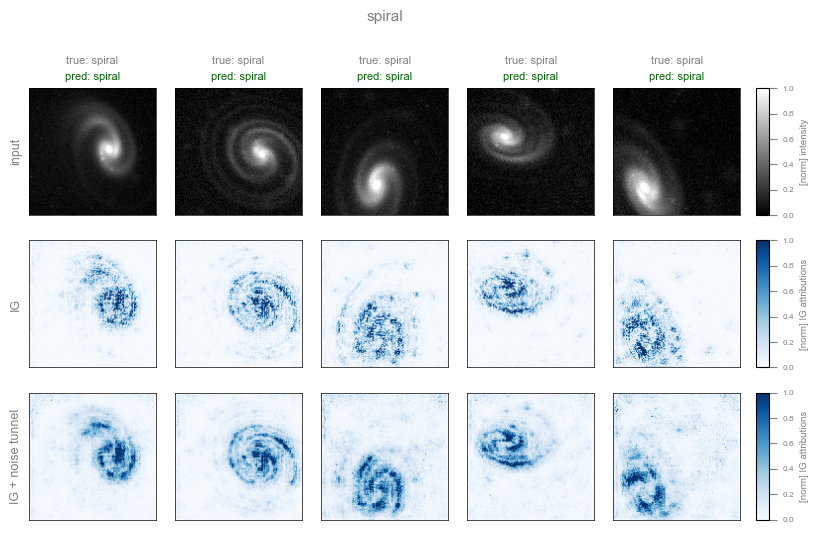

done.


In [80]:
def gal_saliency(model, x, target):
    """Vanilla saliency: |gradient of the target logit w.r.t. the input|."""
    x = x.clone().detach().requires_grad_(True)   # gradients on the input
    score = model(x.unsqueeze(0))[0, target]                 # the scalar we explain
    score.backward()
    return x.grad.abs().squeeze(0).cpu()                     # magnitude only


def gal_ig(model, x, target, steps=64):
    """Integrated Gradients: midpoint Riemann sum along baseline -> x."""
    baseline = torch.zeros_like(x)                      # the 'empty sky' image
    alphas = torch.linspace(0, 1, steps + 1)[:-1] + 0.5 / steps
    # all path points stacked into one batch: (steps, C, H, W)
    path = (baseline + alphas[:, None, None, None] * (x - baseline)).requires_grad_(True)
    model(path)[:, target].sum().backward()             # one backward pass fills path.grad
    grads = path.grad
    # displacement x mean path gradient, then drop the (size-1) channel dim
    return ((x - baseline) * grads.mean(0)).squeeze(0).detach().cpu()   # Riemann sum


def gal_ig_noise_tunnel(model, x, target, nt_samples=10, stdev=None, steps=64):
    """Noise tunnel over gal_ig with the `smoothgrad_sq` rule:
    mean of the SQUARED IG maps across nt_samples noisy copies of x.

    stdev=None scales the noise to the image itself (0.5 * x.std()) -- the toy
    galaxies live on a 0-3 scale with std ~0.27, so a fixed stdev=1.0 would drown the signal and make every map look hazy.
    """
    if stdev is None:
        stdev = 0.5 * x.std().item()
    attrs = []
    for _ in range(nt_samples):
        noisy = x + stdev * torch.randn_like(x)
        attrs.append(gal_ig(model, noisy, target, steps=steps) ** 2)
    return torch.stack(attrs).mean(0).sqrt()             # RMS, not raw MSE:
    # squaring then averaging (smoothgrad_sq) shrinks small values far more than
    # large ones (0.2^2 is 25x smaller than 1.0^2, not just 5x) -- the final sqrt
    # undoes that so faint-but-real structure isn't invisible next to strong peaks.


# ---- completeness check: sum(IG) should equal F(x) - F(baseline) ---------
print("running the IG completeness check on one example image...")
xg = example_images[CLASSES[0]][0]
with torch.no_grad():
    pg = gal_model(xg.unsqueeze(0)).argmax().item()
ig_g = gal_ig(gal_model, xg, pg, steps=256)
with torch.no_grad():
    delta = (gal_model(xg.unsqueeze(0))[0, pg]
             - gal_model(torch.zeros_like(xg).unsqueeze(0))[0, pg]).item()
print(f"  sum(IG) = {ig_g.sum():.3f}   F(x) - F(baseline) = {delta:.3f}   "
      f"(these should match -- that's completeness)")

# ---- which classes to actually print below -- edit this list -------------
CATEGORIES_TO_SHOW = ["spiral"]        # e.g. ["elliptical", "spiral"] for two,
                                        # or CLASSES for all six

# ---- for each requested class: the 5 saved example images x (input / IG / IG+noise tunnel) ----
print(f"generating attribution grids for {len(CATEGORIES_TO_SHOW)} classes, 5 examples each...")
for cls in range(len(CLASSES)):
    cls_name = CLASSES[cls]
    if cls_name not in CATEGORIES_TO_SHOW:
        continue
    imgs = example_images[cls_name]
    true_labels = example_true[cls_name]

    ncols = len(imgs)
    # a dedicated colorbar column (own axis, not carved out of the last image subplot)
    fig, axes = plt.subplots(3, ncols + 1, figsize=(1.7 * ncols + 1.1, 5.6),
                              gridspec_kw={"width_ratios": [1] * ncols + [0.1], "wspace": 0.1})
    img_axes, cbar_axes = axes[:, :ncols], axes[:, ncols]
    row_im = [None, None, None]
    for j in range(ncols):
        xg = imgs[j]
        true_cls = int(true_labels[j])
        with torch.no_grad():
            pg = gal_model(xg.unsqueeze(0)).argmax().item()
        ig_j = gal_ig(gal_model, xg, pg).abs()
        nt_j = gal_ig_noise_tunnel(gal_model, xg, pg, nt_samples=10)

        input_norm = xg.squeeze() / xg.max().clamp(min=1e-8)
        row_im[0] = img_axes[0, j].imshow(input_norm, cmap="gray", vmin=0, vmax=1)
        ax0 = img_axes[0, j]
        ax0.text(0.5, 1.18, f"true: {CLASSES[true_cls]}", transform=ax0.transAxes,
                 ha="center", va="bottom", fontsize=8)
        ax0.text(0.5, 1.05, f"pred: {CLASSES[pg]}", transform=ax0.transAxes,
                 ha="center", va="bottom", fontsize=8,
                 color="darkgreen" if pg == true_cls else "black")
        for r, amap, cmap in [(1, ig_j, "Blues"), (2, nt_j, "Blues")]:
            vmax = torch.quantile(amap.flatten(), 0.99).clamp(min=1e-8)   # contrast stretch
            amap_norm = (amap / vmax).clamp(0, 1)                        # -> [0, 1]
            row_im[r] = img_axes[r, j].imshow(amap_norm, cmap=cmap, vmin=0, vmax=1)
        for r in range(3):
            clean_axis(img_axes[r, j])

    row_labels = ["input", "IG", "IG + noise tunnel"]
    cbar_labels = ["[norm] intensity", "[norm] IG attributions", "[norm] IG attributions"]
    for r, (label, cbar_label) in enumerate(zip(row_labels, cbar_labels)):
        img_axes[r, 0].text(-0.15, 0.5, label, transform=img_axes[r, 0].transAxes,
                            rotation=90, va="center", fontsize=9)
        cbar = fig.colorbar(row_im[r], cax=cbar_axes[r])
        cbar.outline.set_visible(True)
        cbar.outline.set_linewidth(0.8)
        cbar.outline.set_edgecolor("black")
        cbar.set_label(cbar_label, fontsize=7)
        cbar.ax.tick_params(labelsize=6, width=0.8)
    fig.suptitle(CLASSES[cls], fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()

print(f"done.")


<div class="alert alert-danger" role="alert" style="border-radius: 8px; padding: 10px;">

<b>[End of solution]</b>

</div>

**Reading the grid above:** saliency is mostly noisy, as expected — a single gradient snapshot, so it points to the *broad region* of the image, not a clean map.

- **Elliptical** (correctly predicted): attribution concentrates on the **central bulge** — no disk or arms to look at.
- **Spiral**: saliency barely hints at it, but IG and the noise-tunnel-averaged IG show structure beyond the bulge — the model uses **bulge *and* spiral arms**, not just the bright core.
- **Barred spiral**: IG and the noise tunnel trace the **bar and spiral arms** together — the model picks up the extended morphology, not just brightness.
- **Merger**: attribution spreads across **multiple sources and their tidal features**, consistent with a multi-source interacting system rather than one smooth galaxy.

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit; box-sizing: border-box; max-width: 100%; overflow-wrap: break-word;">

<font size=4>**Question**</font>

Our IG baseline was a black image — "empty sky". Real survey images have **sky background and noise**. Is all-zeros still the right notion of *absence of signal*?

</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a; box-sizing: border-box; max-width: 100%; overflow-wrap: break-word;">
<details>

<b><summary>[Spoiler] (click here to expand)</summary></b>

Not necessarily. IG answers <i>"what changed relative to the baseline?"</i> — with an all-zeros baseline on real images, the sky itself differs from the baseline and gets attribution. A better "no galaxy" reference is often the <b>sky level</b> (e.g. median background) or a blurred copy of the image. The baseline is a <i>modeling choice</i>: pick the one matching your scientific question.

</details>
</div>

## Circuit diagram: what is `gal_model` actually looking at for a barred spiral?

Same circuit-drawing recipe as the MNIST section: **gradient × activation** gives a contribution score per channel/unit at every stage; we keep the top-k units per stage as the **circuit** and draw each with its own activation map as a thumbnail. Applied to `gal_model`'s four stages (`conv1` → `conv2` → `conv3` → `fc1`) for a correctly-classified **barred spiral**. Purely for visualisation, to have an estimate of which features in the activation maps are 'firing'

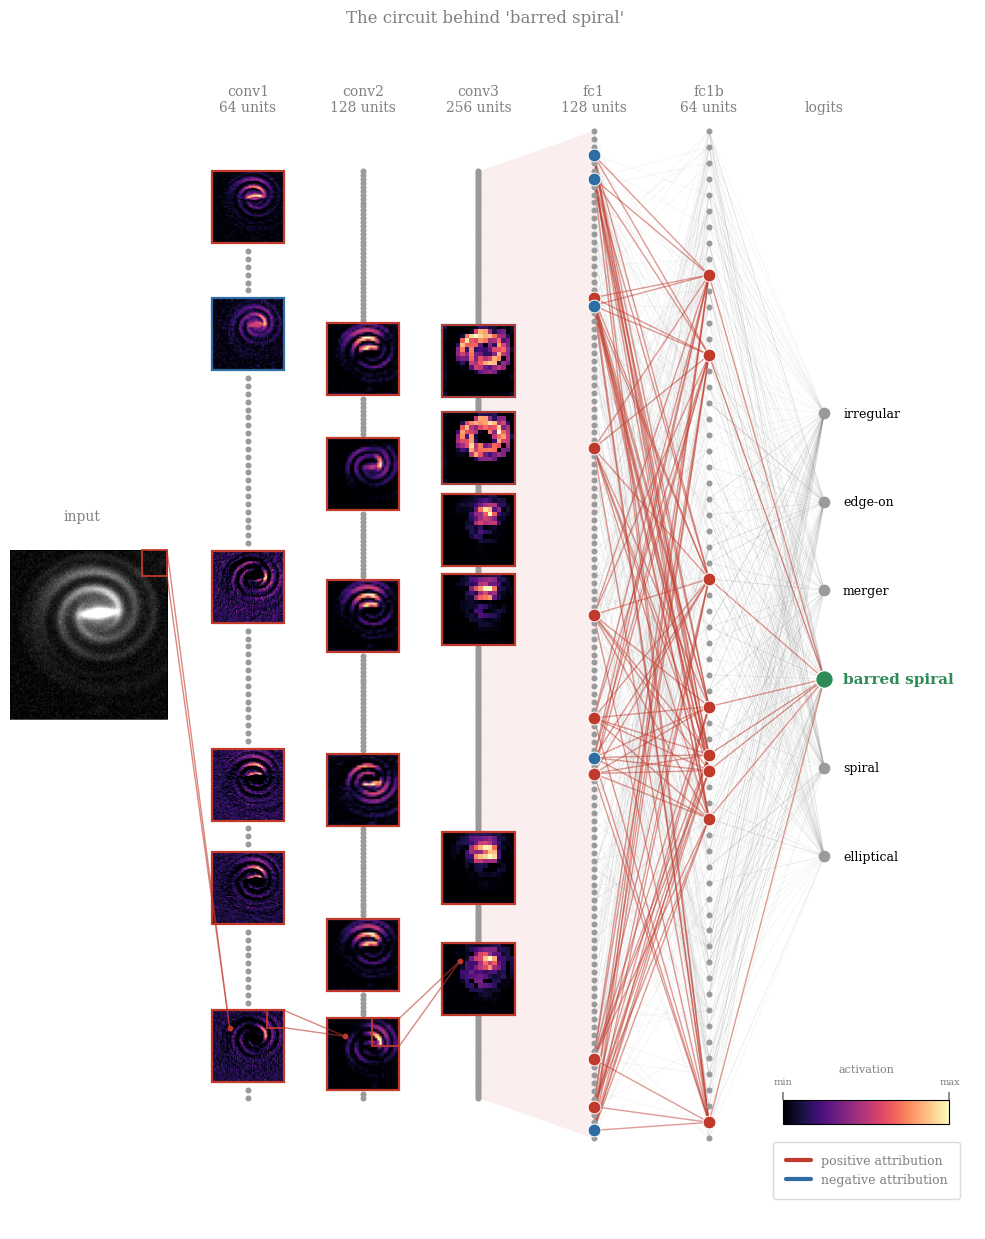

In [81]:
import os
import numpy as np
import torch
import torch.nn.functional as F

from helpers import draw_circuit

# ---- load the held-out test split from disk -- self-sufficient, does not
# depend on gal_Xte/gal_yte still being in memory from an earlier cell ------
GAL_DATA_DIR = "data/gal_data"
gal_Xte = torch.from_numpy(np.load(os.path.join(GAL_DATA_DIR, "gal_Xte.npy")))
gal_yte = torch.from_numpy(np.load(os.path.join(GAL_DATA_DIR, "gal_yte.npy")))

# ---- pick a correctly-predicted barred spiral test example -----------
barred_idx = CLASSES.index("barred spiral")
candidates = (gal_yte == barred_idx).nonzero(as_tuple=True)[0]
img = None
for i in candidates.tolist():
    xi = gal_Xte[i]
    with torch.no_grad():
        if gal_model(xi.unsqueeze(0)).argmax().item() == barred_idx:
            img = xi
            break
assert img is not None, "no correctly-classified barred spiral in the test set"
p = barred_idx
x = img.unsqueeze(0)

# forward pass, keeping the intermediate activations (so autograd can give
# us gradients w.r.t. each stage)
a1 = F.max_pool2d(F.relu(gal_model.bn1(gal_model.conv1(x))), 2)     # (1, 32, 32, 32)
a2 = F.max_pool2d(F.relu(gal_model.bn2(gal_model.conv2(a1))), 2)    # (1, 64, 16, 16)
a3 = F.max_pool2d(F.relu(gal_model.bn3(gal_model.conv3(a2))), 2)    # (1, 128, 8, 8)
a4 = F.relu(gal_model.fc1(a3.flatten(1)))                            # (1, 128)
a5 = F.relu(gal_model.fc1b(a4))                                       # (1, 64)
logits_vec = gal_model.fc2(a5)[0]                                    # (4,)
stages = [("conv1", a1), ("conv2", a2), ("conv3", a3), ("fc1", a4), ("fc1b", a5)]

top_k = [6, 6, 6, 12, 8]
tops = draw_circuit(stages, logits_vec, p, CLASSES, img,
                     input_display=(img.squeeze(), "gray"), top_k=top_k)


<div style="border-left: 4px solid #4CAF50; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #e8f5e9; color: #1a1a1a; box-sizing: border-box; max-width: 100%; overflow-wrap: break-word;">

**NOTE:** Everything from the MNIST section transfers directly: compare `gal_saliency` and `gal_ig` side by side, try a **white baseline** in `gal_ig`, find the *arm-detector* neuron via its favorite test images, or re-discover the circuit on subsampled data to see which neurons are **stable**.

</div>

# Takeaways

**Saliency** $= |\partial F / \partial x|$: one backward pass, exact for linear models — but **blind to saturated features**. Use it as a quick look, never as evidence.

**Integrated gradients**: a path integral of gradients from a **baseline** to the input. Restores attribution under saturation; **completeness** ($\sum_i \mathrm{IG}_i = F(x) - F(x')$) gives a built-in correctness check. Costs: `steps` (watch the completeness gap) and the baseline — *part of the question you ask*, not an implementation detail.

**Mechanistic explainability** attributes the output to internal units instead of pixels: **exact** at the last layer (just read off the weighted-sum addends), via gradient $\times$ activation deeper down. Chaining this stage by stage yields a **circuit**: the minimal cross-layer subnetwork carrying the prediction. Circuit membership depends on the scoring data; *certified circuits* (Anani et al. 2026) make it provably stable.

<div style="border-left: 4px solid #4CAF50; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #e8f5e9; color: #1a1a1a; box-sizing: border-box; max-width: 100%; overflow-wrap: break-word;">

<b>Important take-away message #2</b>

Explainability claims are <i>hypotheses</i>. Test them: check completeness, ablate the neurons, perturb the dataset. Only claims that survive all three belong in your paper.

</div>

## References

- Simonyan, Vedaldi & Zisserman (2013), *Deep Inside Convolutional Networks* — [arXiv:1312.6034](https://arxiv.org/abs/1312.6034)
- Sundararajan, Taly & Yan (2017), *Axiomatic Attribution for Deep Networks* — [arXiv:1703.01365](https://arxiv.org/abs/1703.01365)
- Olah et al. (2020), *Zoom In: An Introduction to Circuits* — [distill.pub/2020/circuits/zoom-in](https://distill.pub/2020/circuits/zoom-in)
- Anani, Lorenz, Schiele, Fritz & Fischer (2026), *Certified Circuits: Stability Guarantees for Mechanistic Circuits* — [arXiv:2602.22968](https://arxiv.org/abs/2602.22968), [code](https://github.com/AlaaAnani/certified-circuits)

## Beyond This Notebook

You now know the basics and theory: saliency, IG, noise tunnels, and circuits. [Captum](https://captum.ai/) is a PyTorch explainability library implementing these and more, including non-gradient methods like SHAP and occlusion-based attribution — useful when you can't backpropagate through a model at all. Worth exploring before hand-rolling this again.

$\rightarrow$ [captum.ai](https://captum.ai/)


<img src="images/captum.png" style="display:block; margin-left:auto; margin-right:auto;">


In [ ]:
###EOF